# Forecasting Notebook


In [ ]:
#Imports & Configuration

import pandas as pd
import numpy as np
import time
import warnings
import json
import logging
import os
from pathlib import Path
from scipy.optimize import minimize
from scipy import stats as sp_stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# Scikit-learn: preprocessing & imputation
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor

# Scikit-learn: model selection & evaluation
from sklearn.model_selection import (
    cross_val_predict, cross_val_score, KFold,
    GridSearchCV, RandomizedSearchCV, ParameterSampler
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.base import clone as _sk_clone

# Scikit-learn: linear models
from sklearn.linear_model import (
    Ridge, Lasso, ElasticNet, LinearRegression,
    RidgeCV, LassoCV
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor

# Boosting libraries
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Optional libraries (with fallbacks)
try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    STATSMODELS_OK = True
except ImportError:
    STATSMODELS_OK = False
    print("statsmodels not available — ETS baseline will be skipped")

try:
    from catboost import CatBoostRegressor
    CATBOOST_AVAILABLE = True
except ImportError:
    CATBOOST_AVAILABLE = False
    print("CatBoost not installed — CatBoost model excluded from leaderboard")

warnings.filterwarnings('ignore')
np.random.seed(42)

output_dir = '1_Models_Comparison_output'
os.makedirs(output_dir, exist_ok=True)

# Global constants 
RANDOM_STATE   = 42
CV_FOLDS       = 5          # folds for cross-sectional CV (one row per parish)
DATA_PATH      = "../input/data_before_1acc.csv"

print(" All imports loaded successfully.")


 All imports loaded successfully.


## 1. Data Loading & Temporal Split

**Scientific rule**: target window is the last 12 months per parish. Training data is everything strictly before that window. This is enforced per-parish since parishes have different end dates.

In [5]:
# Data Loading
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])

for col in ['energy_kwh', 't2m', 'tp']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.sort_values(['parish_code', 'date']).reset_index(drop=True)

# Per-parish temporal split 
# Target window: last 12 months for each parish (they may end at different dates)
df_target = df.groupby('parish_code').tail(12).reset_index(drop=True)

# Cutoff date: the EARLIEST date in each parish's target window
cutoff_dates = (
    df_target.groupby('parish_code')['date'].min()
    .rename('cutoff_date')
)

# Training data: strictly before the cutoff date (no temporal overlap)
df_merged = df.merge(cutoff_dates, on='parish_code')
df_input  = df_merged[df_merged['date'] < df_merged['cutoff_date']].copy()
df_input  = df_input.drop(columns=['cutoff_date'])

# Target variable: mean of the 12-month window per parish 
Y = (
    df_target.groupby('parish_code')['energy_kwh']
    .mean()
    .rename('actual_target_mean')
)

print(f"Parishes           : {Y.shape[0]}")
print(f"Training rows      : {len(df_input):,}")
print(f"Target rows        : {len(df_target):,}")
print(f"Training months    : min={df_input.groupby('parish_code').size().min()},  "
      f"median={df_input.groupby('parish_code').size().median():.0f},  "
      f"max={df_input.groupby('parish_code').size().max()}")

# No overlap
max_input_date = df_input.groupby('parish_code')['date'].max()
min_target_date = df_target.groupby('parish_code')['date'].min()
assert (max_input_date < min_target_date).all(), "TEMPORAL OVERLAP DETECTED"
print("\n Temporal split validated: zero overlap between input and target.")


Parishes           : 173
Training rows      : 5,775
Target rows        : 2,076
Training months    : min=21,  median=35,  max=36

 Temporal split validated: zero overlap between input and target.


## 2. Feature Engineering

Two complementary feature sets are built:

**A. Cross-sectional features**:  produce one row per parish, aggregated entirely from df_input. These feed the regularised regression models (Ridge, Lasso, ElasticNet) and the tree-based models (XGBoost, Random Forest).

**B. Panel (monthly-row) features**: produce one row per parish-month pair, with lags computed within df_input. These are used by the global panel models, LightGBM and CatBoost.


## 2.1 Cross-Sectional Feature Extraction

In [6]:
# Feature Engineering 
# Cross-sectional feature matrix (one row per parish)

def build_cross_sectional_features(df_in: pd.DataFrame, Y_index) -> pd.DataFrame:
    rows = []
    for parish, group in df_in.sort_values(['parish_code', 'date']).groupby('parish_code'):
        g  = group.reset_index(drop=True)
        e  = g['energy_kwh']
        n  = len(e)

        # Lag features (strictly from training window)
        lag_12 = e.iloc[-12] if n >= 12 else np.nan
        lag_24 = e.iloc[-24] if n >= 24 else np.nan
        lag_36 = e.iloc[-36] if n >= 36 else np.nan

        # Rolling stats
        roll_3  = e.tail(3).mean()
        roll_6  = e.tail(6).mean()
        roll_12 = e.tail(12).mean()
        roll_24 = e.tail(24).mean() if n >= 24 else roll_12

        # Trend & momentum 
        momentum_3_6  = roll_3 / roll_6  if roll_6 > 0 else 1.0
        momentum_6_12 = roll_6 / roll_12 if roll_12 > 0 else 1.0
        yoy_ratio     = roll_12 / roll_24 if (roll_24 > 0 and not np.isnan(roll_24)) else 1.0
        lag_spread    = (lag_12 - lag_24) if not np.isnan(lag_24) else 0.0

        # Linear trend slope (last 24 available months)
        window = min(24, n)
        slope  = 0.0
        if window >= 3:
            x_tr = np.arange(window)
            y_tr = e.tail(window).values
            mask = ~np.isnan(y_tr)
            if mask.sum() >= 3:
                slope = np.polyfit(x_tr[mask], y_tr[mask], 1)[0]

        # Volatility 
        volatility = e.std()
        cv_energy  = volatility / roll_12 if roll_12 > 0 else 0.0

        # Weather features 
        recent_t2m = g['t2m'].tail(12).mean()
        recent_tp  = g['tp'].tail(12).mean()
        hist_t2m   = g['t2m'].mean()
        hist_tp    = g['tp'].mean()
        t2m_trend  = recent_t2m - hist_t2m

        # Calendar
        holiday_rate = g['n_holidays'].mean()
        last_month   = int(g['month'].iloc[-1])

        rows.append({
            'parish_code'    : parish,
            'lag_12'         : lag_12,
            'lag_24'         : lag_24,
            'lag_36'         : lag_36,
            'lag_spread'     : lag_spread,
            'roll_3'         : roll_3,
            'roll_6'         : roll_6,
            'roll_12'        : roll_12,
            'roll_24'        : roll_24,
            'momentum_3_6'   : momentum_3_6,
            'momentum_6_12'  : momentum_6_12,
            'yoy_ratio'      : yoy_ratio,
            'slope'          : slope,
            'volatility'     : volatility,
            'cv_energy'      : cv_energy,
            'recent_t2m'     : recent_t2m,
            'recent_tp'      : recent_tp,
            'hist_t2m'       : hist_t2m,
            'hist_tp'        : hist_tp,
            't2m_trend'      : t2m_trend,
            'holiday_rate'   : holiday_rate,
            'last_month'     : last_month,
        })

    feat_df = pd.DataFrame(rows).set_index('parish_code')
    return feat_df.loc[Y_index]


X_cs = build_cross_sectional_features(df_input, Y.index)
print(f"Cross-sectional feature matrix: {X_cs.shape}")

# Panel (monthly-row) features — for global LightGBM / CatBoost

df_panel = df_input.copy()
df_panel = df_panel.sort_values(['parish_code', 'date'])
df_panel['lag_12'] = df_panel.groupby('parish_code')['energy_kwh'].shift(12)
df_panel['lag_13'] = df_panel.groupby('parish_code')['energy_kwh'].shift(13)
df_panel['lag_24'] = df_panel.groupby('parish_code')['energy_kwh'].shift(24)

# Interaction / polynomial features on training panel
df_panel['temp_x_month']     = df_panel['t2m'] * df_panel['month']
df_panel['energy_momentum']  = df_panel['lag_12'] - df_panel['lag_13']
df_panel['t2m_sq']           = df_panel['t2m'] ** 2
df_panel['tp_log1p']         = np.log1p(df_panel['tp'])

# Drop rows where lag_12 is unavailable (first 12 rows per parish)
df_panel_clean = df_panel.dropna(subset=['lag_12', 'lag_13']).copy()

# Features for the panel model
PANEL_FEATURES = [
    'parish_code', 'month', 'year', 't2m', 'tp', 'n_holidays',
    'lag_12', 'lag_13', 'lag_24',
    'temp_x_month', 'energy_momentum', 't2m_sq', 'tp_log1p'
]

# Build target-month feature rows

def resolve_target_month_lags(df_tgt, df_in, lag_months_list):

    # (parish_code, date) -> energy_kwh from training data
    lookup = (
        df_in.set_index(['parish_code', 'date'])['energy_kwh']
        .rename('_base')
    )
    result = df_tgt[['parish_code', 'date', 'month', 'year', 't2m', 'tp',
                      'n_holidays']].copy()
    for lag in lag_months_list:
        lag_dates = result['date'] - pd.DateOffset(months=lag)
        keys = list(zip(result['parish_code'], lag_dates))
        result[f'lag_{lag}'] = [lookup.get(k, np.nan) for k in keys]
    return result

df_target_panel = resolve_target_month_lags(
    df_target, df_input, lag_months_list=[12, 13, 24]
)

# Add interaction features for target panel
df_target_panel['temp_x_month']    = df_target_panel['t2m'] * df_target_panel['month']
df_target_panel['energy_momentum'] = df_target_panel['lag_12'] - df_target_panel['lag_13']
df_target_panel['t2m_sq']          = df_target_panel['t2m'] ** 2
df_target_panel['tp_log1p']        = np.log1p(df_target_panel['tp'])

print(f"Panel training rows   : {len(df_panel_clean):,}")
print(f"Panel target rows     : {len(df_target_panel):,}")
print(f"Target panel lag_12 nulls: {df_target_panel['lag_12'].isnull().sum()}")
print("\n Feature engineering complete")


Cross-sectional feature matrix: (173, 21)
Panel training rows   : 3,526
Panel target rows     : 2,076
Target panel lag_12 nulls: 0

 Feature engineering complete


## 2.2 Strict Forward Chronological CV (CER-appearance ordering)

`KFold(shuffle=False)` is effectively random with respect to when each parish's renewable-energy community appeared. Parishes with earlier cutoff dates have shorter training histories, so mixing them randomly into folds lets the model borrow patterns from parishes with longer histories to predict shorter ones.

`ChronoForwardSplit` fixes this by sorting parishes by cutoff date and splitting into n_splits + 1 chronological bins. The oldest bin is always training-only; each subsequent fold trains only on parishes whose CER appeared earlier than the validation bin.

Hyperparameters are still tuned with GridSearchCV / RandomizedSearchCV using an inner ChronoForwardSplit on each outer fold. forward_oof_predict replaces cross_val_predict because the warm-up bin is intentionally never validated, dropping OOF coverage from 100% to ~83%. The N eval column in the results below reflects this.

In [7]:
# Strict Forward Chronological CV (train only on older-CER parishes)

class ChronoForwardSplit:

    """Expanding-window CV grouped by parish CER appearance
    
    Warm-up bin = oldest parishes, training-only (no validation fold for them).
    The rest gets split into n_splits validation folds chronologically.

    Parameters
    ----------
    cutoff_dates : pd.Series indexed by parish_code
    n_splits : int, default 5
    min_train_frac : float in (0, 1), default 0.5
        How much of the data goes into the warm-up bin.
        Bigger = more training data for fold 1.
    """

    def __init__(self, cutoff_dates, n_splits=5, min_train_frac=0.5):
        if not 0.0 < min_train_frac < 1.0:
            raise ValueError("min_train_frac must be in (0, 1)")
        self.cutoff_dates = cutoff_dates
        self.n_splits = n_splits
        self.min_train_frac = min_train_frac

    def _bin_assign(self, parishes):

        # bin 0 = warm-up only, bins 1..n_splits are validation folds
        n = len(parishes)
        cutoffs = self.cutoff_dates.reindex(parishes).values
        order = np.argsort(cutoffs, kind='stable')
        rank = np.empty(n, dtype=int); rank[order] = np.arange(n)
        warmup_n = max(1, int(round(n * self.min_train_frac)))
        val_n = n - warmup_n
        val_bin_size = max(1.0, val_n / self.n_splits)
        bins = np.zeros(n, dtype=int)
        in_val = rank >= warmup_n
        val_rank = rank - warmup_n
        bins[in_val] = np.minimum((val_rank[in_val] / val_bin_size).astype(int),
                                   self.n_splits - 1) + 1
        return bins

    def split(self, X, y=None, groups=None):
        if hasattr(X, 'index'):
            parishes = list(X.index)
        else:
            parishes = list(self.cutoff_dates.index[:len(X)])
        bins = self._bin_assign(parishes)
        for k in range(1, self.n_splits + 1):
            tr = np.where(bins < k)[0]  
            te = np.where(bins == k)[0]
            if len(tr) > 0 and len(te) > 0:
                yield tr, te

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

def forward_oof_predict(estimator, X, y, cv):
    """
    Returns out-of-fold predictions and per-fold validation MAEs.
    Predictions for the initial warm-up cohort will be NaN.
    """
    y_index = y.index if hasattr(y, 'index') else None
    preds = pd.Series(np.nan, index=y_index, name='oof_pred')
    fold_maes = []
    for k, (tr, te) in enumerate(cv.split(X, y)):
        est = _sk_clone(estimator)
        Xtr = X.iloc[tr] if hasattr(X, 'iloc') else X[tr]
        ytr = y.iloc[tr] if hasattr(y, 'iloc') else y[tr]
        Xte = X.iloc[te] if hasattr(X, 'iloc') else X[te]
        yte = y.iloc[te] if hasattr(y, 'iloc') else y[te]
        est.fit(Xtr, ytr)
        p = est.predict(Xte)
        preds.iloc[te] = p
        fold_maes.append(float(np.mean(np.abs(p - np.asarray(yte)))))
    return preds, fold_maes


# Setup outer/inner cross-validation loops
CV_OUTER = ChronoForwardSplit(cutoff_dates, n_splits=CV_FOLDS, min_train_frac=0.5)
CV_INNER = ChronoForwardSplit(cutoff_dates, n_splits=3,        min_train_frac=0.5)

# Verify dataset date range bounds
_chk = cutoff_dates.sort_values()
print(f"Parishes: {len(_chk)}")
print(f"  earliest cutoff: {_chk.iloc[0].date()}  (CER appeared first)")
print(f"  latest   cutoff: {_chk.iloc[-1].date()}  (CER appeared last / no CER)")


_order = pd.Index(X_cs.index.astype(str))
_bins = CV_OUTER._bin_assign(_order)
n_training_only = int((_bins == 0).sum())
print(f"\nChronoForwardSplit folds (strict forward, train on older-CER parishes only):")
print(f"  Initial training-only cohort: {n_training_only} parishes (oldest ACC/CER date bin; no earlier parishes exist to validate them)")
print(f"  Out-of-fold evaluated parishes : {len(X_cs) - n_training_only}  "
      f"(~{(1 - n_training_only/len(X_cs))*100:.0f}% coverage)")
for k, (tr, te) in enumerate(CV_OUTER.split(X_cs, Y)):
    train_cuts = cutoff_dates.reindex(X_cs.index[tr])
    test_cuts  = cutoff_dates.reindex(X_cs.index[te])
    relation = "OK" if train_cuts.max() < test_cuts.min() else "CHECK"
    print(f"  fold {k}: train {len(tr):3d} (..{train_cuts.max().date()})  "
          f"val {len(te):3d} ({test_cuts.min().date()}..{test_cuts.max().date()}) [{relation}]")

def safe_mae(y_true, y_pred):
    # Drop NaNs from the warm-up parishes
    from sklearn.metrics import mean_absolute_error as _mae
    yt = np.asarray(y_true); yp = np.asarray(y_pred)
    mask = np.isfinite(yp) & np.isfinite(yt)
    if mask.sum() == 0:
        return float('nan')
    return _mae(yt[mask], yp[mask])


print("\nStrict-forward chronological CV ready.")

Parishes: 173
  earliest cutoff: 2022-08-01  (CER appeared first)
  latest   cutoff: 2023-11-01  (CER appeared last / no CER)

ChronoForwardSplit folds (strict forward, train on older-CER parishes only):
  Initial training-only cohort: 86 parishes (oldest ACC/CER date bin; no earlier parishes exist to validate them)
  Out-of-fold evaluated parishes : 87  (~50% coverage)
  fold 0: train  86 (..2023-10-01)  val  18 (2023-10-01..2023-10-01) [CHECK]
  fold 1: train 104 (..2023-10-01)  val  17 (2023-10-01..2023-10-01) [CHECK]
  fold 2: train 121 (..2023-10-01)  val  18 (2023-10-01..2023-10-01) [CHECK]
  fold 3: train 139 (..2023-10-01)  val  17 (2023-10-01..2023-10-01) [CHECK]
  fold 4: train 156 (..2023-10-01)  val  17 (2023-10-01..2023-11-01) [CHECK]

Strict-forward chronological CV ready.


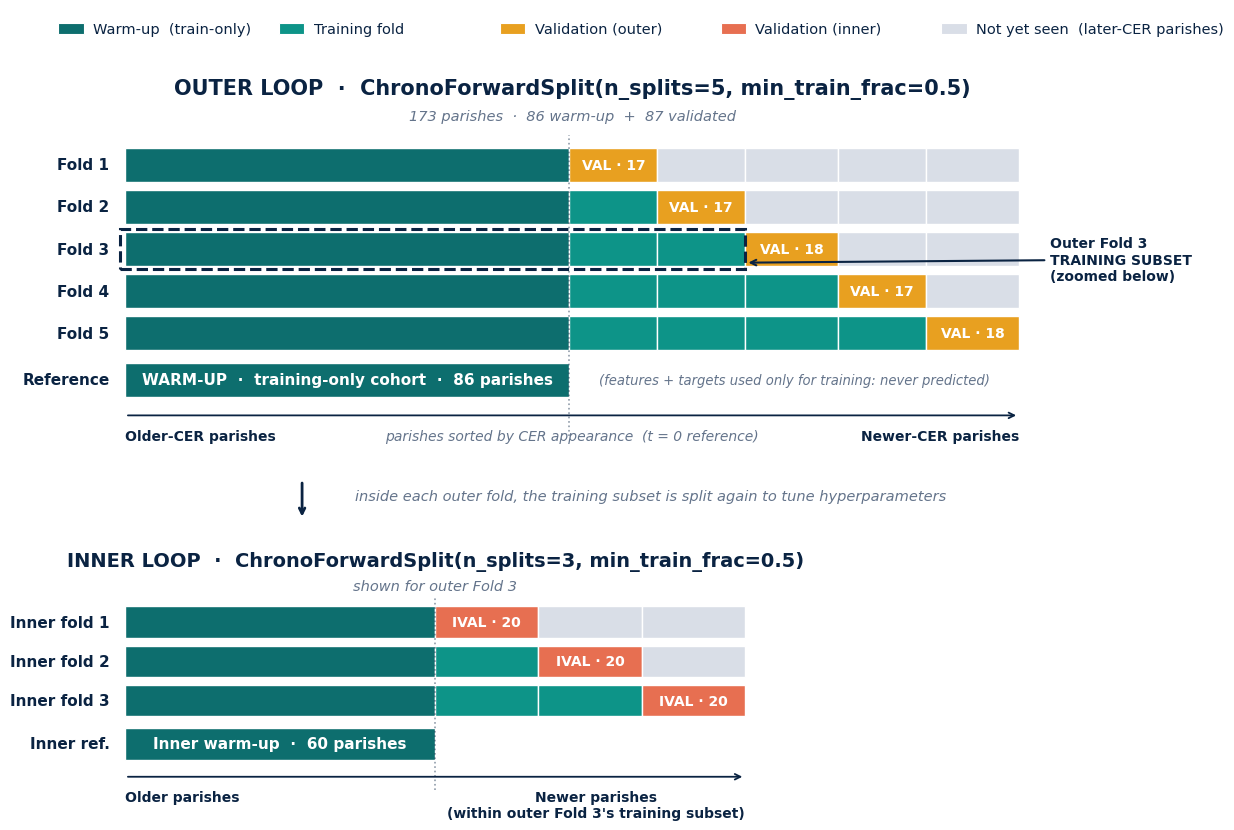

Wrote cv_scheme_nested.png


In [ ]:
#Nested CV scheme visualisation
from matplotlib.patches import Rectangle

OUT = 'cv_scheme_nested.png'

# Palette
NAVY      = '#0A2342'
TEAL_DARK = '#0D6E6E'
TEAL_MED  = '#0D9488'
AMBER     = '#E8A020'
ROSE      = '#E76F51'
GREY      = '#D9DEE7'
MUTED     = '#64748B'
BG        = '#F8FAFC'

# Sizes
WARMUP = 86
OUTER_VAL = [17, 17, 18, 17, 18]
OUTER_BINS = [0, WARMUP]
for s in OUTER_VAL:
    OUTER_BINS.append(OUTER_BINS[-1] + s)
TOTAL = OUTER_BINS[-1]

ZOOM_FOLD = 3
zoom_train_end = OUTER_BINS[ZOOM_FOLD]
zoom_val_start = OUTER_BINS[ZOOM_FOLD]
zoom_val_end   = OUTER_BINS[ZOOM_FOLD + 1]

INNER_TOTAL  = zoom_train_end
INNER_WARMUP = int(round(INNER_TOTAL * 0.5))
inner_rem    = INNER_TOTAL - INNER_WARMUP
iv_base      = inner_rem // 3
iv_extra     = inner_rem - iv_base * 3
INNER_VAL    = [iv_base + (1 if k < iv_extra else 0) for k in range(3)]
INNER_BINS   = [0, INNER_WARMUP]
for s in INNER_VAL:
    INNER_BINS.append(INNER_BINS[-1] + s)

# Figure: 4 stacked panels via gridspec
#   row 0: legend strip
#   row 1: outer loop title + outer-loop bars (combined)
#   row 2: small label strip "Now zooming into..."
#   row 3: inner loop title + inner-loop bars (combined)
fig = plt.figure(figsize=(15, 10.5), facecolor='white')
gs = fig.add_gridspec(
    4, 1, height_ratios=[0.45, 5.0, 0.55, 3.5], hspace=0.10,
)
ax_legend = fig.add_subplot(gs[0])
ax_outer  = fig.add_subplot(gs[1])
ax_bridge = fig.add_subplot(gs[2])
ax_inner  = fig.add_subplot(gs[3])
for ax in (ax_legend, ax_outer, ax_bridge, ax_inner):
    ax.set_facecolor('white')
    for s in ['top', 'right', 'left', 'bottom']:
        ax.spines[s].set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])

ROW_H = 0.78
GAP   = 0.18

def cell(ax, x0, x1, y, color, label=None, label_color='white',
         size=11, weight='bold'):
    ax.add_patch(Rectangle((x0, y), x1 - x0, ROW_H,
                            facecolor=color, edgecolor='white', linewidth=1.0))
    if label:
        ax.text((x0 + x1) / 2, y + ROW_H / 2, label,
                ha='center', va='center', fontsize=size,
                fontweight=weight, color=label_color)

# ── ROW 0: Legend strip ─────────────────────────────────────────────────────
ax = ax_legend
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
swatches = [
    (TEAL_DARK,  'Warm-up  (train-only)'),
    (TEAL_MED,   'Training fold'),
    (AMBER,      'Validation (outer)'),
    (ROSE,       'Validation (inner)'),
    (GREY,       'Not yet seen  (later-CER parishes)'),
]
# Compute horizontal positions
n = len(swatches)
xs = [0.04 + i * 0.19 for i in range(n)]
sw_w, sw_h = 0.022, 0.30
sw_y = 0.30
for x, (col, lbl) in zip(xs, swatches):
    ax.add_patch(Rectangle((x, sw_y), sw_w, sw_h, facecolor=col,
                            edgecolor='white', linewidth=0.8))
    ax.text(x + sw_w + 0.008, sw_y + sw_h/2, lbl, ha='left', va='center',
            fontsize=10.5, color=NAVY)

# ── ROW 1: Outer loop ───────────────────────────────────────────────────────
ax = ax_outer
ax.set_xlim(-22, TOTAL + 30)

# Title (inside the panel, no overlap because we reserved vertical space)
y_title = 7.85
ax.text(TOTAL/2, y_title,
        'OUTER LOOP  ·  ChronoForwardSplit(n_splits=5, min_train_frac=0.5)',
        ha='center', va='bottom', fontsize=15, fontweight='bold', color=NAVY)
ax.text(TOTAL/2, y_title - 0.55,
        f'{TOTAL} parishes  ·  {WARMUP} warm-up  +  {TOTAL - WARMUP} validated',
        ha='center', va='bottom', fontsize=10.5, color=MUTED, style='italic')

# Folds 1..5 drawn top to bottom
fold_y_for = []
fold_y_top = 5.95
for k in range(5):
    y = fold_y_top - k * (ROW_H + GAP)
    fold_y_for.append(y)
    cell(ax, 0, WARMUP, y, TEAL_DARK)
    for prev in range(k):
        cell(ax, OUTER_BINS[1+prev], OUTER_BINS[2+prev], y, TEAL_MED)
    cell(ax, OUTER_BINS[1+k], OUTER_BINS[2+k], y, AMBER,
         f'VAL · {OUTER_VAL[k]}', size=10)
    for fut in range(k+1, 5):
        cell(ax, OUTER_BINS[1+fut], OUTER_BINS[2+fut], y, GREY)
    ax.text(-3, y + ROW_H/2, f'Fold {k+1}', ha='right', va='center',
            fontsize=11, fontweight='bold', color=NAVY)

# Reference row (warm-up only)
y_ref = fold_y_top - 5 * (ROW_H + GAP) - 0.10
cell(ax, 0, WARMUP, y_ref, TEAL_DARK,
     f'WARM-UP  ·  training-only cohort  ·  {WARMUP} parishes')
ax.text(WARMUP + sum(OUTER_VAL)/2, y_ref + ROW_H/2,
        '(features + targets used only for training: never predicted)',
        ha='center', va='center', fontsize=9.5, color=MUTED, style='italic')
ax.text(-3, y_ref + ROW_H/2, 'Reference', ha='right', va='center',
        fontsize=11, fontweight='bold', color=NAVY)

# Dotted vertical at warm-up boundary
ax.axvline(WARMUP, color=NAVY, linestyle=':', linewidth=1.2, alpha=0.45,
           ymin=0.06, ymax=0.82)

# Chronological axis at the bottom of the outer panel
axis_y = y_ref - 0.42
ax.annotate('', xy=(TOTAL, axis_y), xytext=(0, axis_y),
            arrowprops=dict(arrowstyle='->', color=NAVY, lw=1.3))
ax.text(0, axis_y - 0.32, 'Older-CER parishes',
        ha='left', va='top', fontsize=10, color=NAVY, fontweight='bold')
ax.text(TOTAL, axis_y - 0.32, 'Newer-CER parishes',
        ha='right', va='top', fontsize=10, color=NAVY, fontweight='bold')
ax.text(TOTAL/2, axis_y - 0.32,
        'parishes sorted by CER appearance  (t = 0 reference)',
        ha='center', va='top', fontsize=10, color=MUTED, style='italic')

# Highlight the zoom fold with a dashed box (only over training portion)
y_zoom = fold_y_for[ZOOM_FOLD - 1]
ax.add_patch(Rectangle((-1, y_zoom - 0.06), zoom_train_end + 1, ROW_H + 0.12,
                        facecolor='none', edgecolor=NAVY, linewidth=2.2,
                        linestyle='--', zorder=10))

# Right-side annotation for the zoomed fold (well clear of cells)
ann_x = TOTAL + 6
ax.annotate(
    f'Outer Fold {ZOOM_FOLD}\nTRAINING SUBSET\n(zoomed below)',
    xy=(zoom_train_end + 0.10, y_zoom + 0.08),
    xytext=(ann_x, y_zoom + ROW_H/2 - 0.24),
    ha='left', va='center', fontsize=10, fontweight='bold', color=NAVY,
    arrowprops=dict(arrowstyle='->', color=NAVY, lw=1.5,
                    connectionstyle='arc3,rad=0'),
)

ax.set_ylim(axis_y - 1.0, y_title + 0.8)

# ── ROW 2: Bridge ───────────────────────────────────────────────────────────
ax = ax_bridge
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
# Down-arrow + caption, offset so they do not overlap
ax.annotate('', xy=(0.25, 0.05), xytext=(0.25, 0.95),
            arrowprops=dict(arrowstyle='->', color=NAVY, lw=2.0))
ax.text(0.55, 0.58,
        'inside each outer fold, the training subset is split again to tune hyperparameters',
        ha='center', va='center', fontsize=10.5, color=MUTED, style='italic')

# ── ROW 3: Inner loop ───────────────────────────────────────────────────────
ax = ax_inner
ax.set_xlim(-22, TOTAL + 30)

inner_title_y = 5.30
ax.text(INNER_TOTAL/2, inner_title_y,
        'INNER LOOP  ·  ChronoForwardSplit(n_splits=3, min_train_frac=0.5)',
        ha='center', va='bottom', fontsize=14, fontweight='bold', color=NAVY)
ax.text(INNER_TOTAL/2, inner_title_y - 0.55,
        f'shown for outer Fold {ZOOM_FOLD}',
        ha='center', va='bottom', fontsize=10.5, color=MUTED, style='italic')

# 3 inner folds drawn top to bottom
inner_y_top = 3.65
for k in range(3):
    y = inner_y_top - k * (ROW_H + GAP)
    cell(ax, 0, INNER_WARMUP, y, TEAL_DARK)
    for prev in range(k):
        cell(ax, INNER_BINS[1+prev], INNER_BINS[2+prev], y, TEAL_MED)
    cell(ax, INNER_BINS[1+k], INNER_BINS[2+k], y, ROSE,
         f'IVAL · {INNER_VAL[k]}', size=10)
    for fut in range(k+1, 3):
        cell(ax, INNER_BINS[1+fut], INNER_BINS[2+fut], y, GREY)
    ax.text(-3, y + ROW_H/2, f'Inner fold {k+1}', ha='right', va='center',
            fontsize=11, fontweight='bold', color=NAVY)

# Inner reference (warm-up-only of the outer-training subset)
inner_y_ref = inner_y_top - 3 * (ROW_H + GAP) - 0.10
cell(ax, 0, INNER_WARMUP, inner_y_ref, TEAL_DARK,
     f'Inner warm-up  ·  {INNER_WARMUP} parishes')
ax.text(-3, inner_y_ref + ROW_H/2, 'Inner ref.', ha='right', va='center',
        fontsize=11, fontweight='bold', color=NAVY)

ax.axvline(INNER_WARMUP, color=NAVY, linestyle=':', linewidth=1.2, alpha=0.45,
           ymin=0.10, ymax=0.8)

# Chronological axis for inner panel
axis_y_inner = inner_y_ref - 0.42
ax.annotate('', xy=(INNER_TOTAL, axis_y_inner), xytext=(0, axis_y_inner),
            arrowprops=dict(arrowstyle='->', color=NAVY, lw=1.3))
ax.text(0, axis_y_inner - 0.32, 'Older parishes',
        ha='left', va='top', fontsize=10, color=NAVY, fontweight='bold')
ax.text(INNER_TOTAL, axis_y_inner - 0.32,
        f'Newer parishes                  \n(within outer Fold {ZOOM_FOLD}\'s training subset)',
        ha='right', va='top', fontsize=10, color=NAVY, fontweight='bold')

ax.set_ylim(axis_y_inner - 1.0, inner_title_y + 0.75)

plt.savefig(OUT, dpi=170, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Wrote {OUT}")


## 3. Naive Baselines (no fitting)

Before building any proper machine learning models, we need a baseline to beat. We'll run four simple, parameter-free predictors side-by-side to see how they perform on the data:

1. **Global mean**: Every parish gets the exact same prediction: the overall average across the entire training set. This ignores both location and time.

2. **Parish overall mean**: Every parish is predicted using its own historical average from the training window, weighting all training months equally.
   
3. **Last-value**: Predicts a parish's annual mean using only its single most recent training observation.
4. **Seasonal naive**: Predicts a parish's annual mean using the average of its last 12 training months, capturing recency *and* annual seasonality.

Whichever approach yields the lowest MAE will become our primary benchmark. While we expect the seasonal naive approach to perform best, we'll let the initial run prove it.


Building 12-month vector target matrix...
  Y_vec shape: (173, 12)  (parishes x target months)
Training multi-output Ridge (nested CV)...
Training multi-output XGBoost...


  12-MONTH VECTOR FORECAST LEADERBOARD
                     Model        MAE    MAE_min    MAE_max Time (s)
        12m Naive (vector)     0.0597     0.0506     0.0712      0.0
  12m Ridge (multi-output)     0.0663     0.0449     0.0885      8.9
12m XGBoost (multi-output)     0.1192     0.0989     0.1555      1.5


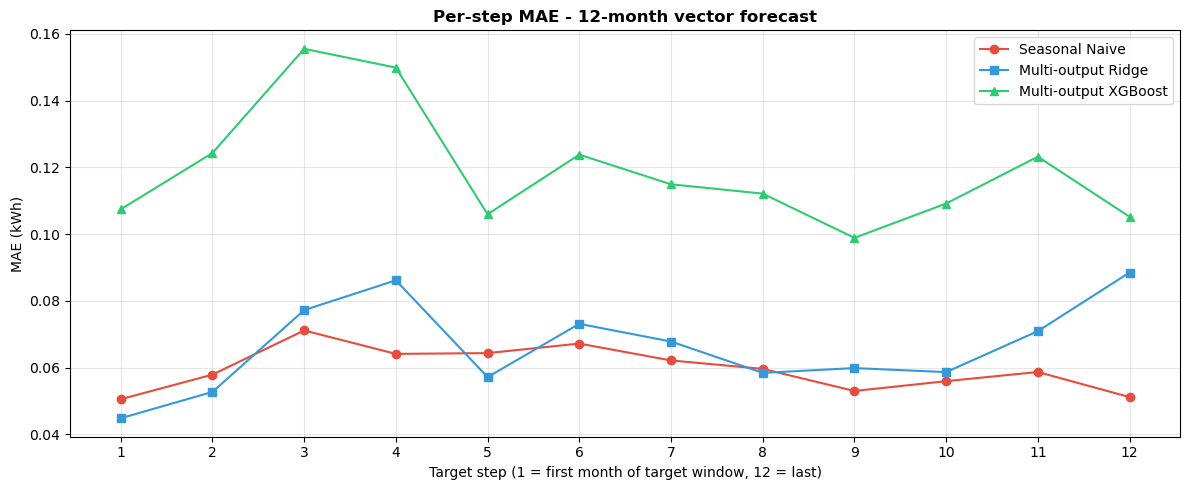


Reconciliation with Task A (annual mean derived from vector forecast):
  Multi-output Ridge  -> annual-mean MAE:     0.0472  (cf. Task-A Ridge MAE:     0.0422)
  Multi-output XGB    -> annual-mean MAE:     0.0913  (cf. Task-A XGB   MAE:     0.1044)

Task B (12-month vector forecast) complete


In [ ]:
# Second Predictive Task: 12-month vector forecast

print("Building 12-month vector target matrix...")

# -- Build Y_vec: one row per parish, 12 columns (target months in chronological order)
df_target_sorted = df_target.sort_values(['parish_code', 'date']).copy()
df_target_sorted['target_step'] = (
    df_target_sorted.groupby('parish_code').cumcount()  # 0..11 per parish
)
Y_vec = (
    df_target_sorted
    .pivot(index='parish_code', columns='target_step', values='energy_kwh')
    .reindex(Y.index)
)
Y_vec.columns = [f'step_{i+1:02d}' for i in range(12)]
print(f"  Y_vec shape: {Y_vec.shape}  (parishes x target months)")

# 1. Seasonal Naive (vector) - replay the 12 months immediately before cutoff
naive_vec_rows = []
for parish, g in df_input.sort_values(['parish_code', 'date']).groupby('parish_code'):
    last12 = g['energy_kwh'].tail(12).values
    if len(last12) < 12:
        last12 = np.concatenate([np.full(12 - len(last12), last12.mean()), last12])
    naive_vec_rows.append((parish, *last12))
naive_vec = pd.DataFrame(
    naive_vec_rows,
    columns=['parish_code'] + [f'step_{i+1:02d}' for i in range(12)]
).set_index('parish_code').reindex(Y_vec.index)

# 2. Multi-output Ridge (nested CV: alpha tuned per outer fold)
print("Training multi-output Ridge (nested CV)...")
start = time.time()
ridge_vec_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
    ('model',   Ridge()),
])
ridge_vec_gs = GridSearchCV(
    ridge_vec_pipe,
    {'model__alpha': [0.1, 1, 10, 50, 100, 500]},
    cv=ChronoForwardSplit(cutoff_dates, n_splits=3),
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)
ridge_vec_model = MultiOutputRegressor(ridge_vec_gs, n_jobs=-1)
# cross_val_predict is incompatible with ChronoForwardSplit because
# warm-up parishes are intentionally never assigned to validation folds.
ridge_vec_preds = pd.DataFrame(
    np.nan,
    index=Y_vec.index,
    columns=Y_vec.columns
)

for fold_id, (tr_idx, te_idx) in enumerate(KF_CS.split(X_cs), start=1):
    X_tr, X_te = X_cs.iloc[tr_idx], X_cs.iloc[te_idx]
    Y_tr = Y_vec.iloc[tr_idx]

    fold_model = MultiOutputRegressor(ridge_vec_gs, n_jobs=-1)
    fold_model.fit(X_tr, Y_tr)

    ridge_vec_preds.iloc[te_idx] = fold_model.predict(X_te)

time_ridge_vec = time.time() - start

#  3. Multi-output XGBoost 
print("Training multi-output XGBoost...")
start = time.time()
xgb_vec_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   XGBRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        random_state=RANDOM_STATE, tree_method='hist', verbosity=0)),
])
xgb_vec_model = MultiOutputRegressor(xgb_vec_pipe, n_jobs=-1)
xgb_vec_preds = pd.DataFrame(
    np.nan,
    index=Y_vec.index,
    columns=Y_vec.columns
)

for fold_id, (tr_idx, te_idx) in enumerate(KF_CS.split(X_cs), start=1):
    X_tr, X_te = X_cs.iloc[tr_idx], X_cs.iloc[te_idx]
    Y_tr = Y_vec.iloc[tr_idx]

    fold_model = MultiOutputRegressor(xgb_vec_pipe, n_jobs=-1)
    fold_model.fit(X_tr, Y_tr)

    xgb_vec_preds.iloc[te_idx] = fold_model.predict(X_te)

time_xgb_vec = time.time() - start

#   per-step MAE and overall MAE
def vector_metrics(y_true_df, y_pred_df, name, t):
    diff = (y_true_df - y_pred_df).abs()
    per_step = diff.mean(axis=0, skipna=True)
    overall  = np.nanmean(diff.values)
    return per_step.rename(name), {
        'Model'   : name,
        'MAE'     : overall,
        'MAE_min' : per_step.min(),
        'MAE_max' : per_step.max(),
        'Time (s)': t,
    }

ps_naive, sum_naive = vector_metrics(Y_vec, naive_vec,        '12m Naive (vector)', 0.0)
ps_ridge, sum_ridge = vector_metrics(Y_vec, ridge_vec_preds, '12m Ridge (multi-output)', time_ridge_vec)
ps_xgb,   sum_xgb   = vector_metrics(Y_vec, xgb_vec_preds,   '12m XGBoost (multi-output)', time_xgb_vec)

vector_leaderboard = pd.DataFrame([sum_naive, sum_ridge, sum_xgb]).sort_values('MAE')
print("\n")
print("  12-MONTH VECTOR FORECAST LEADERBOARD")
vl_disp = vector_leaderboard.copy()
for k in ['MAE', 'MAE_min', 'MAE_max']:
    vl_disp[k] = vl_disp[k].map('{:>10.4f}'.format)
vl_disp['Time (s)'] = vl_disp['Time (s)'].map('{:.1f}'.format)
print(vl_disp.to_string(index=False))

# Per-step plot: how does error change across the 12-month horizon
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(range(1, 13), ps_naive.values, marker='o', label='Seasonal Naive', color='#e74c3c')
ax.plot(range(1, 13), ps_ridge.values, marker='s', label='Multi-output Ridge', color='#3498db')
ax.plot(range(1, 13), ps_xgb.values,   marker='^', label='Multi-output XGBoost', color='#2ecc71')
ax.set_xlabel('Target step (1 = first month of target window, 12 = last)')
ax.set_ylabel('MAE (kWh)')
ax.set_title('Per-step MAE - 12-month vector forecast', fontweight='bold')
ax.set_xticks(range(1, 13))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('1_Models_Comparison_output/vector_forecast_per_step.png', dpi=150, bbox_inches='tight')
plt.show()

# Reconciliation check: does the *mean* of the vector forecast match Task A?
ridge_vec_annual_mean = ridge_vec_preds.mean(axis=1)
xgb_vec_annual_mean   = xgb_vec_preds.mean(axis=1)
print("\nReconciliation with Task A (annual mean derived from vector forecast):")
print(f"  Multi-output Ridge  -> annual-mean MAE: {safe_mae(Y, ridge_vec_annual_mean):>10.4f}  "
      f"(cf. Task-A Ridge MAE: {safe_mae(Y, ridge_series):>10.4f})")
print(f"  Multi-output XGB    -> annual-mean MAE: {safe_mae(Y, xgb_vec_annual_mean):>10.4f}  "
      f"(cf. Task-A XGB   MAE: {safe_mae(Y, xgb_series):>10.4f})")

print("\nTask B (12-month vector forecast) complete")



In [8]:
# Seasonal Naive Baselines 

print("Computing all naive baselines...")

# Global mean: one mean for every parish
start = time.time()
global_mean_value = df_input['energy_kwh'].mean()
global_naive_preds = pd.Series(
    np.full(len(Y), global_mean_value), index=Y.index, name='global_naive_pred'
)
time_global_naive = time.time() - start

# Parish overall mean: each parish's historical mean across all training months
start = time.time()
parish_overall_mean = (
    df_input.groupby('parish_code')['energy_kwh'].mean()
    .rename('parish_mean_naive_pred').reindex(Y.index)
)
time_parish_mean_naive = time.time() - start

# Last-value: most recent training observation per parish
start = time.time()
last_value_pred = (
    df_input.sort_values(['parish_code', 'date'])
    .groupby('parish_code')['energy_kwh'].last()
    .rename('last_value_naive_pred').reindex(Y.index)
)
time_last_naive = time.time() - start

# Seasonal naive: mean of the last 12 training months per parish
start = time.time()
naive_preds = (
    df_input.sort_values(['parish_code', 'date'])
    .groupby('parish_code')
    .tail(12)
    .groupby('parish_code')['energy_kwh']
    .mean()
    .rename('naive_pred')
    .reindex(Y.index)
)
time_naive = time.time() - start

# Evaluate performance and speed
naive_summary = pd.DataFrame({
    'Naive':         ['Global mean',     'Parish overall mean',  'Last value',       'Seasonal (last-12 mean)'],
    'MAE':           [safe_mae(Y, global_naive_preds),
                      safe_mae(Y, parish_overall_mean),
                      safe_mae(Y, last_value_pred),
                      safe_mae(Y, naive_preds)],
    'Time (s)':      [time_global_naive, time_parish_mean_naive, time_last_naive,    time_naive],
})
naive_summary = naive_summary.sort_values('MAE').reset_index(drop=True)

print("\n")
print("  NAIVE BASELINES: side-by-side (lower MAE is better)")
disp = naive_summary.copy()
disp['MAE']      = disp['MAE'].map('{:>10.4f}'.format)
disp['Time (s)'] = disp['Time (s)'].map('{:.2f}'.format)
print(disp.to_string(index=False))

# Declare the benchmark
best_naive_name = naive_summary.iloc[0]['Naive']
best_naive_mae  = naive_summary.iloc[0]['MAE']

print(f"\nWinning naive baseline: '{best_naive_name}'  (MAE {best_naive_mae:>10.4f})")
print(f"\nBest baseline: {best_naive_name} (MAE: {best_naive_mae:.4f})")
if 'Seasonal' in best_naive_name:
    print("Using this as the baseline to beat for future models.")
else:
    print("Be careful, a simpler baseline beat the seasonal one.")


Computing all naive baselines...


  NAIVE BASELINES: side-by-side (lower MAE is better)
                  Naive        MAE Time (s)
Seasonal (last-12 mean)     0.0463     0.01
    Parish overall mean     0.0499     0.00
             Last value     0.0980     0.01
            Global mean     1.1665     0.00

Winning naive baseline: 'Seasonal (last-12 mean)'  (MAE     0.0463)

Best baseline: Seasonal (last-12 mean) (MAE: 0.0463)
Using this as the baseline to beat for future models.


## 4. Baseline Fitted Models

## 4.1 First Fitted Models: ETS and Linear Regression

With the seasonal naive model establishing our baseline MAE, we have a clear target to beat. We begin our modeling with two straightforward approaches. The logic is simple: if these foundational models cannot outperform the seasonal naive baseline, our more complex machine learning challengers later on are unlikely to do so either.

- **ETS (Holt-Winters)**: Modeled on a per-parish basis, this approach optimizes parameters to capture level, trend, and a 12-month seasonal pattern. It is strictly univariate, relying entirely on each parish's historical data without incorporating external covariates. To handle shorter time series, we implemented a three-tier fallback system: it attempts a full seasonal fit, drops to trend-only if data is insufficient, and defaults to a 12-month seasonal-naive mean as a final resort.

- **Linear Regression**: This model takes a cross-sectional approach, utilizing our engineered feature matrix (X_cs). To ensure rigorous evaluation, we test it using a strict, forward-chronological cross-validation.

The section below outlines the overall MAE for each model, alongside a fold-by-fold breakdown for the Linear Regression to demonstrate how the expanding training window influences performance over time.


In [9]:
# ETS and Linear Regression (first fitted models)

# ETS per parish (with short-history fallback) 
print("Fitting per-parish ETS...")
start = time.time()
ets_preds = {}
ets_success = 0
ets_trend_only = 0
ets_full_fallback = 0
ets_error_examples = []
for parish, group in df_input.sort_values(['parish_code','date']).groupby('parish_code'):
    ts = group['energy_kwh'].values
    pred = None; last_err = None
    # 1) Full seasonal Holt-Winters (needs >= 24 months for 12-month seasonality)
    if len(ts) >= 24:
        try:
            m = ExponentialSmoothing(ts, trend='add', seasonal='add',
                                        seasonal_periods=12,
                                        initialization_method='estimated')
            fit = m.fit(optimized=True)
            pred = fit.forecast(12).mean()
            if not np.isfinite(pred): pred = None
        except Exception as ex:
            last_err = ex; pred = None
    # 2) Trend-only fallback (no seasonality, works on shorter series)
    if pred is None and len(ts) >= 6:
        try:
            m = ExponentialSmoothing(ts, trend='add', seasonal=None,
                                        initialization_method='estimated')
            fit = m.fit(optimized=True)
            pred = fit.forecast(12).mean()
            if not np.isfinite(pred): pred = None
            else: ets_trend_only += 1
        except Exception as ex:
            last_err = ex; pred = None
    # 3) Last resort: seasonal-naive value
    if pred is None:
        pred = ts[-12:].mean()
        ets_full_fallback += 1
        if len(ets_error_examples) < 3 and last_err is not None:
            ets_error_examples.append(f"{parish}: {type(last_err).__name__}: {last_err}")
    else:
        ets_success += 1
    ets_preds[parish] = pred

ets_series = pd.Series(ets_preds, name='ets_pred').reindex(Y.index)
time_ets = time.time() - start
mae_ets = safe_mae(Y, ets_series)
ets_diff_from_naive = int((np.abs(ets_series - naive_preds) > 1.0).sum())

print(f"  ETS MAE: {mae_ets:>10.4f}  ({time_ets:.1f}s)")
print(f"  Full seasonal fits   : {ets_success - ets_trend_only}/{len(Y)}")
print(f"  Trend-only fallback  : {ets_trend_only}/{len(Y)}  (<24 months of history)")
print(f"  Seasonal-naive fallback: {ets_full_fallback}/{len(Y)}")
print(f"  ETS predictions distinct from seasonal naive: {ets_diff_from_naive}/{len(Y)}")
if ets_error_examples:
    print("  Example errors hit before fallback: " + " | ".join(ets_error_examples))

# 2. Linear Regression (Cross-sectional feature matrix)
print("\nFitting linear regression under strict-forward chronological CV...")
start = time.time()
KF_CS = CV_OUTER   # strict forward chronological (older-CER parishes train first)

lr_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
    ('model',   LinearRegression()),
])
lr_preds, lr_fold_maes = forward_oof_predict(lr_pipe, X_cs, Y, cv=KF_CS)
lr_series = lr_preds.rename('lr_pred')
time_lr = time.time() - start
mae_lr = safe_mae(Y, lr_series)

print(f"  Linear regression MAE: {mae_lr:>10.4f}  ({time_lr:.2f}s)")
print(f"  Per-fold MAE: " + ", ".join(f"{m:.4f}" for m in lr_fold_maes))

# Compare performance against baseline
print(f"\nVs seasonal-naive benchmark (MAE {safe_mae(Y, naive_preds):>10.4f}):")
print(f"  ETS               : {'beats' if mae_ets < safe_mae(Y, naive_preds) else 'loses to'} benchmark "
      f"(delta {mae_ets - safe_mae(Y, naive_preds):>10.4f})")
print(f"  Linear regression : {'beats' if mae_lr < safe_mae(Y, naive_preds) else 'loses to'} benchmark "
      f"(delta {mae_lr - safe_mae(Y, naive_preds):>10.4f})")



Fitting per-parish ETS...
  ETS MAE:     0.0582  (10.5s)
  Full seasonal fits   : 172/173
  Trend-only fallback  : 1/173  (<24 months of history)
  Seasonal-naive fallback: 0/173
  ETS predictions distinct from seasonal naive: 1/173

Fitting linear regression under strict-forward chronological CV...
  Linear regression MAE:     0.0404  (0.10s)
  Per-fold MAE: 0.0401, 0.0314, 0.0294, 0.0696, 0.0321

Vs seasonal-naive benchmark (MAE     0.0463):
  ETS               : loses to benchmark (delta     0.0119)
  Linear regression : beats benchmark (delta    -0.0059)


## 5. Regularised Linear Models (Ridge / Lasso / ElasticNet)

With roughly 21 features across 173 parishes, our cross-sectional feature matrix runs a slight risk of overfitting. To handle this, we introduce regularization via Ridge, Lasso, and ElasticNet to penalize overly complex coefficients and improve out-of-sample generalization.

To ensure a rigorous evaluation, we wrap the hyperparameter tuning inside a nested cross-validation loop, preventing any data leakage between the parameter search and our final validation tracking.


In [10]:
# Regularised Linear Models (Ridge / Lasso / ElasticNet)

def cv_regularised(model_cls, param_grid, name, X, y, cv):
    """
    Fits a regularized linear model using nested cross-validation.
    
    Wraps the pipeline in a GridSearchCV to optimize hyperparameters 
    on the training data before generating out-of-fold predictions.
    """

    # Use chronological splits for the inner tuning loop
    inner_cv = ChronoForwardSplit(cutoff_dates, n_splits=3)
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  RobustScaler()),
        ('model',   model_cls()),
    ])
    gs = GridSearchCV(pipe, param_grid, cv=inner_cv,
             scoring='neg_mean_absolute_error', n_jobs=-1)
    preds, fold_maes = forward_oof_predict(gs, X, y, cv=cv)
    print(f"  {name} per-fold MAE: " + ", ".join(f"{m:.4f}" for m in fold_maes))
    return preds.rename(f'{name}_pred')

print("Training regularised models (nested CV)...")
start = time.time()

KF_CS = CV_OUTER   # strict forward chronological (older-ACC training only)

alpha_ridge = {'model__alpha': [0.01, 0.1, 1, 10, 50, 100, 500, 1000]}
alpha_lasso = {'model__alpha': [0.001, 0.01, 0.1, 1, 10, 50]}
alpha_en    = {'model__alpha': [0.01, 0.1, 1, 10],
               'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]}

ridge_series = cv_regularised(Ridge,      alpha_ridge, 'ridge', X_cs, Y, KF_CS)
lasso_series = cv_regularised(Lasso,      alpha_lasso, 'lasso', X_cs, Y, KF_CS)
en_series    = cv_regularised(ElasticNet, alpha_en,    'en',    X_cs, Y, KF_CS)

time_reg = time.time() - start

print(f"  Ridge      MAE: {safe_mae(Y, ridge_series):>10.4f}")
print(f"  Lasso      MAE: {safe_mae(Y, lasso_series):>10.4f}")
print(f"  ElasticNet MAE: {safe_mae(Y, en_series):>10.4f}")
print(f"\n Regularised models complete ({time_reg:.1f}s)")


Training regularised models (nested CV)...
  ridge per-fold MAE: 0.0412, 0.0300, 0.0328, 0.0735, 0.0343
  lasso per-fold MAE: 0.0547, 0.0375, 0.0413, 0.0691, 0.0429
  en per-fold MAE: 0.0405, 0.0443, 0.0376, 0.0818, 0.0417
  Ridge      MAE:     0.0422
  Lasso      MAE:     0.0491
  ElasticNet MAE:     0.0490

 Regularised models complete (6.3s)


## 6. Tree based models

## 6.1. Tuned XGBoost (Cross-Sectional)

Using the same nested cross-validation pattern as the regularized linear models, we apply XGBoost to our 21-feature cross-sectional matrix.

While linear models assume additive effects, XGBoost is introduced here to capture non-linear interactions between parish-level features, such as how a high historical volatility combined with an upward temperature trend might non-linearly compound energy risk. Because we are working with a relatively small sample size of 173 parishes, we intentionally restrict the tree depth and apply strict regularization to keep the model from overfitting.


In [11]:
#XGBoost (nested forward-chrono CV with randomized inner search)

print("Tuning XGBoost (nested RandomizedSearchCV)...")
start = time.time()

xgb_dist = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [2, 3, 4],
    'learning_rate':    [0.01, 0.05, 0.1],
    'subsample':        [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha':        [0, 0.1, 1],
    'reg_lambda':       [0.5, 1, 2],
}

xgb_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   XGBRegressor(random_state=RANDOM_STATE,
                              tree_method='hist', verbosity=0)),
])

inner_cv_xgb = ChronoForwardSplit(cutoff_dates, n_splits=3)
xgb_rs = RandomizedSearchCV(xgb_pipe, {'model__' + k: v for k, v in xgb_dist.items()},
             n_iter=40, cv=inner_cv_xgb,
             scoring='neg_mean_absolute_error',
             random_state=RANDOM_STATE, n_jobs=-1)

xgb_series, xgb_fold_maes = forward_oof_predict(xgb_rs, X_cs, Y, cv=KF_CS)
xgb_series = xgb_series.rename('xgb_pred')
print(f"  XGB per-fold MAE: " + ", ".join(f"{m:.4f}" for m in xgb_fold_maes))

time_xgb = time.time() - start
print(f"  XGBoost (tuned) MAE: {safe_mae(Y, xgb_series):>10.4f}  ({time_xgb:.1f}s)")
print(" XGBoost complete.")


Tuning XGBoost (nested RandomizedSearchCV)...
  XGB per-fold MAE: 0.1878, 0.1063, 0.0759, 0.0743, 0.0746
  XGBoost (tuned) MAE:     0.1044  (3.7s)
 XGBoost complete.


## 6.2 Tuned Random Forest (Randomized Search)

We apply a Random Forest regressor to the cross-sectional feature matrix using the same nested cross-validation structure. To efficiently navigate the larger parameter space, we use a randomized search (RandomizedSearchCV) on the inner training folds.

In [12]:
# Random Forest (nested forward-chrono CV with randomized inner search)

print("Tuning Random Forest (nested RandomizedSearchCV)...")
start = time.time()

rf_dist = {
    'n_estimators':     [200, 400],
    'max_depth':        [None, 5, 8],
    'min_samples_leaf': [1, 3, 5],
    'max_features':     [0.5, 0.7, 'sqrt'],
}

rf_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   RandomForestRegressor(random_state=RANDOM_STATE)),
])

inner_cv_rf = ChronoForwardSplit(cutoff_dates, n_splits=3)
rf_rs = RandomizedSearchCV(rf_pipe, {'model__' + k: v for k, v in rf_dist.items()},
            n_iter=30, cv=inner_cv_rf,
            scoring='neg_mean_absolute_error',
            random_state=RANDOM_STATE, n_jobs=-1)

rf_series, rf_fold_maes = forward_oof_predict(rf_rs, X_cs, Y, cv=KF_CS)
rf_series = rf_series.rename('rf_pred')
print(f"  RF per-fold MAE: " + ", ".join(f"{m:.4f}" for m in rf_fold_maes))

time_rf = time.time() - start
print(f"  Random Forest (tuned) MAE: {safe_mae(Y, rf_series):>10.4f}  ({time_rf:.1f}s)")


Tuning Random Forest (nested RandomizedSearchCV)...
  RF per-fold MAE: 0.1693, 0.0695, 0.0432, 0.0639, 0.0575
  Random Forest (tuned) MAE:     0.0813  (18.3s)


## 6.3 K-Nearest Neighbours and Support Vector Regression

We introduce K-Nearest Neighbors (KNN) and Support Vector Regression (SVR) to expand our cross-sectional model suite with two non-tree, non-linear approaches. Both models are evaluated using the same nested chronological cross-validation pattern to prevent hyperparameter data leakage.

- **K-Nearest Neighbors (KNN)**: This distance-weighted regressor tunes n_neighbors and weights. It is a strong fit for the cross-sectional matrix under the assumption that parishes with similar recent consumption profiles will likely share similar annual averages.

- **Support Vector Regression (SVR)**: Utilizing an RBF kernel, this model tunes C, epsilon, and gamma to capture complex non-linear interactions. Because SVR is highly sensitive to feature scales, it relies directly on the RobustScaler step embedded in the pipeline.


In [13]:
# KNN and SVR (cross-sectional, nested chronological CV)

# KNN 
print("Tuning KNN regressor (nested chronological CV)...")
start = time.time()

knn_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
    ('model',   KNeighborsRegressor()),
])
knn_grid = {
    'model__n_neighbors': [3, 5, 7, 10, 15, 20, 30],
    'model__weights':     ['uniform', 'distance'],
    'model__p':           [1, 2],   # Manhattan / Euclidean distance
}
knn_gs = GridSearchCV(knn_pipe, knn_grid,
             cv=ChronoForwardSplit(cutoff_dates, n_splits=3),
             scoring='neg_mean_absolute_error', n_jobs=-1)
knn_series, knn_fold_maes = forward_oof_predict(knn_gs, X_cs, Y, cv=CV_OUTER)
knn_series = knn_series.rename('knn_pred')
print(f"  KNN per-fold MAE: " + ", ".join(f"{m:.4f}" for m in knn_fold_maes))
time_knn = time.time() - start
print(f"  KNN (tuned) MAE: {safe_mae(Y, knn_series):>10.4f}  ({time_knn:.1f}s)")


# Support Vector Regression 
print("\nTuning SVR (RBF kernel + log1p target, nested chronological CV)...")
start = time.time()

# Inner pipeline: impute + scale + SVR(RBF). Wrapped with log1p target transform.
_svr_inner = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
    ('model',   SVR(kernel='rbf')),
])
svr_pipe = TransformedTargetRegressor(
    regressor=_svr_inner, func=np.log1p, inverse_func=np.expm1
)

# Parameter names get the `regressor__` prefix because of the TransformedTargetRegressor wrapper.
svr_dist = {
    'regressor__model__C':       [0.1, 0.5, 1, 5, 10, 50, 100],
    'regressor__model__epsilon': [0.001, 0.005, 0.01, 0.05, 0.1],
    'regressor__model__gamma':   ['scale', 'auto', 0.01, 0.05, 0.1, 0.5],
}
svr_rs = RandomizedSearchCV(svr_pipe, svr_dist, n_iter=30,
             cv=ChronoForwardSplit(cutoff_dates, n_splits=3),
             scoring='neg_mean_absolute_error',
             random_state=RANDOM_STATE, n_jobs=-1)
svr_series, svr_fold_maes = forward_oof_predict(svr_rs, X_cs, Y, cv=CV_OUTER)
svr_series = svr_series.rename('svr_pred')
print(f"  SVR per-fold MAE: " + ", ".join(f"{m:.4f}" for m in svr_fold_maes))
time_svr = time.time() - start
print(f"  SVR (RBF + log1p, tuned) MAE: {safe_mae(Y, svr_series):>10.4f}  ({time_svr:.1f}s)")



Tuning KNN regressor (nested chronological CV)...
  KNN per-fold MAE: 0.3394, 0.2817, 0.2392, 0.3276, 0.1630
  KNN (tuned) MAE:     0.2706  (5.5s)

Tuning SVR (RBF kernel + log1p target, nested chronological CV)...
  SVR per-fold MAE: 0.0930, 0.0445, 0.0467, 0.0758, 0.0396
  SVR (RBF + log1p, tuned) MAE:     0.0602  (0.9s)


## 7. Sensitivity Check: Panel Formulation (LightGBM)

## 7.1 Sensitivity Check: Panel Formulation (LightGBM)


The previous models all operate on a cross-sectional data shape: one row per parish containing 21 engineered features. Because our prediction target is a single scalar per parish (the 12-month mean), a model that maps one row to one predicted value matches the nature of the task directly.

This section serves as a sensitivity check to determine if a finer, month-level panel representation, where each row represents a unique (parish, month) pair, uncovers additional signal.

| Aspect | Cross-sectional (primary) | Panel (this section, sensitivity) |
|---|---|---|
| Rows | 173 | ~5,300 |
| Unit | one parish | one (parish, month) pair |
| Target during training | mean of last 12 months | each month's energy_kwh |
| Inference for the annual mean | direct | predict 12 target months, then average per parish |
| Pros | matches the task exactly; iid rows | richer monthly structure; more training rows |
| Cons | small N; aggregated features may lose intra-year detail | rows are not iid (repeated observations per parish); inference is indirect; two separate leakage surfaces to control |

Implementation and Validation Strategy

- **Leakage Prevention**: Lags within the panel training dataset (df_panel_clean) were computed using .shift() exclusively on historical data (df_input). To predict target months, features were resolved by looking up historical records from df_input without exposing any information from df_target.

- **Evaluation Protocol**: We apply a temporal expanding-window cross-validation per parish to tune hyperparameters. For final evaluation, the monthly panel predictions are aggregated back into a single annual mean per parish. This allows for a direct, apples-to-apples comparison against the primary cross-sectional leaderboard.

**Note**: In practice, this panel formulation does not outperform our top cross-sectional models. This analysis is preserved to document that alternative data architectures were explored, rather than to serve as a primary production candidate.

In [14]:
# LightGBM Panel Model (Nested Chronological Cross-Validation)

print("Training LightGBM Panel Model (nested chronological OOF)...")
start = time.time()

# Tuning grid and default configurations
lgb_dist = {
    'n_estimators':     [150, 250, 400],
    'learning_rate':    [0.02, 0.05, 0.08],
    'num_leaves':       [15, 31, 63],
    'min_data_in_leaf': [10, 20, 40],
    'feature_fraction': [0.7, 0.85, 1.0],
    'bagging_fraction': [0.8, 0.9, 1.0],
    'bagging_freq':     [1],
}

lgb_default_params = {
    'n_estimators': 250,
    'learning_rate': 0.05,
    'num_leaves': 31,
    'min_data_in_leaf': 20,
    'feature_fraction': 0.85,
    'bagging_fraction': 0.9,
    'bagging_freq': 1,
}

lgbm_panel_series = pd.Series(np.nan, index=Y.index, name='lgbm_panel_pred')
lgbm_fold_maes = []
lgbm_best_params_by_fold = []
lgbm_importance_rows = []

def _prep_lgb_panel_X(df_part):
    X = df_part[PANEL_FEATURES].copy()
    X['parish_code'] = X['parish_code'].astype(str).astype('category')
    return X

# Execute outer cross-validation loop
for fold_id, (tr_idx, te_idx) in enumerate(CV_OUTER.split(X_cs, Y), start=1):
    train_labels = pd.Index(X_cs.index[tr_idx])
    valid_labels = pd.Index(X_cs.index[te_idx])
    train_parishes = pd.Index(train_labels.astype(str))
    valid_parishes = pd.Index(valid_labels.astype(str))

    # Map cross-sectional folds to monthly panel records
    train_panel = df_panel_clean[df_panel_clean['parish_code'].astype(str).isin(train_parishes)].copy()
    valid_target_panel = df_target_panel[df_target_panel['parish_code'].astype(str).isin(valid_parishes)].copy()

    X_tr_lgb = _prep_lgb_panel_X(train_panel)
    y_tr_lgb = train_panel['energy_kwh']
    X_te_lgb = _prep_lgb_panel_X(valid_target_panel)

    inner_cv = ChronoForwardSplit(cutoff_dates, n_splits=3)
    n_inner = inner_cv.get_n_splits(X_tr_lgb, y_tr_lgb)

    if n_inner >= 2:
        lgb_rs = RandomizedSearchCV(
            LGBMRegressor(random_state=RANDOM_STATE, verbose=-1),
            lgb_dist,
            n_iter=10,
            cv=inner_cv,
            scoring='neg_mean_absolute_error',
            random_state=RANDOM_STATE + fold_id,
            n_jobs=-1,
        )
        lgb_rs.fit(X_tr_lgb, y_tr_lgb)
        best_lgb_params = dict(lgb_rs.best_params_)
        tuning_note = f"forward-chrono inner search ({n_inner} splits)"
    else:
        best_lgb_params = dict(lgb_default_params)
        tuning_note = "default params (not enough inner splits)"

    lgbm_fold_model = LGBMRegressor(**best_lgb_params, random_state=RANDOM_STATE, verbose=-1)
    lgbm_fold_model.fit(X_tr_lgb, y_tr_lgb)

    fold_pred_panel = valid_target_panel[['parish_code']].copy()
    fold_pred_panel['parish_code'] = fold_pred_panel['parish_code'].astype(str)
    fold_pred_panel['lgbm_monthly_pred'] = lgbm_fold_model.predict(X_te_lgb)
    fold_pred = (
        fold_pred_panel.groupby('parish_code')['lgbm_monthly_pred']
        .mean()
        .reindex(valid_parishes)
    )
    lgbm_panel_series.loc[valid_labels] = fold_pred.values

    fold_mae = mean_absolute_error(Y.loc[valid_labels], fold_pred)
    lgbm_fold_maes.append(fold_mae)
    lgbm_best_params_by_fold.append(best_lgb_params)
    lgbm_importance_rows.append(lgbm_fold_model.feature_importances_)

    print(f"  fold {fold_id}: train {len(train_parishes):3d} parishes, "
          f"validate {len(valid_parishes):3d}, MAE {fold_mae:>10.4f}  [{tuning_note}]")

# Average importances across outer fold models for feature diagnostics.
lgbm_feature_names = PANEL_FEATURES
lgbm_importances = np.mean(np.vstack(lgbm_importance_rows), axis=0) if lgbm_importance_rows else np.zeros(len(PANEL_FEATURES))
best_lgb_params = lgbm_best_params_by_fold[-1] if lgbm_best_params_by_fold else lgb_default_params

time_lgbm_panel = time.time() - start
print(f"  LightGBM Panel OOF MAE: {safe_mae(Y, lgbm_panel_series):>10.4f}  ({time_lgbm_panel:.1f}s)")
print("  LightGBM fold MAEs: " + ", ".join(f"{m:.4f}" for m in lgbm_fold_maes))





Training LightGBM Panel Model (nested chronological OOF)...
  fold 1: train  86 parishes, validate  18, MAE     0.2030  [forward-chrono inner search (3 splits)]
  fold 2: train 104 parishes, validate  17, MAE     0.1004  [forward-chrono inner search (3 splits)]
  fold 3: train 121 parishes, validate  18, MAE     0.0881  [forward-chrono inner search (3 splits)]
  fold 4: train 139 parishes, validate  17, MAE     0.0825  [forward-chrono inner search (3 splits)]
  fold 5: train 156 parishes, validate  17, MAE     0.0644  [forward-chrono inner search (3 splits)]
  LightGBM Panel OOF MAE:     0.1085  (55.0s)
  LightGBM fold MAEs: 0.2030, 0.1004, 0.0881, 0.0825, 0.0644


## 7.2 Panel Formulation: CatBoost

To complement the LightGBM sensitivity check, we also implement a CatBoost regressor on the same month-level panel structure. This model utilizes CatBoost’s native handling for the categorical parish codes.

Because of compatibility limitations between certain CatBoost versions and scikit-learn's standard RandomizedSearchCV, we use a hand-rolled parameter sampler loop to execute the inner cross-validation search across the training folds.

In [15]:
# CatBoost Panel Model (Nested Chronological Cross-Validation)

print("Training CatBoost Panel Model (nested forward-chrono OOF)...")
start = time.time()

catboost_series = pd.Series(np.nan, index=Y.index, name='catboost_pred')
catboost_fold_maes = []
catboost_best_params_by_fold = []

cb_default_params = {
    'iterations': 250,
    'learning_rate': 0.05,
    'depth': 6,
    'l2_leaf_reg': 3,
}

cb_dist = {
    'iterations': [150, 250],
    'learning_rate': [0.03, 0.05, 0.08],
    'depth': [4, 6],
    'l2_leaf_reg': [3, 10],
}

def _prep_cb_panel_X(df_part):
    X = df_part[PANEL_FEATURES].copy()
    X['parish_code'] = X['parish_code'].astype(str)
    return X

def _fit_catboost_panel(X_train, y_train, params):
    model = CatBoostRegressor(
        **params,
        random_seed=RANDOM_STATE,
        verbose=0,
        cat_features=['parish_code'],
        allow_writing_files=False,
        thread_count=4,
    )
    model.fit(X_train, y_train)
    return model

try:
    # Outer cross-validation loop over the geographical folds
    for fold_id, (tr_idx, te_idx) in enumerate(CV_OUTER.split(X_cs, Y), start=1):
        train_labels = pd.Index(X_cs.index[tr_idx])
        valid_labels = pd.Index(X_cs.index[te_idx])
        train_parishes = pd.Index(train_labels.astype(str))
        valid_parishes = pd.Index(valid_labels.astype(str))

        # Map cross-sectional splits to their corresponding historical panel records
        train_panel = df_panel_clean[df_panel_clean['parish_code'].astype(str).isin(train_parishes)].copy()
        valid_target_panel = df_target_panel[df_target_panel['parish_code'].astype(str).isin(valid_parishes)].copy()

        X_tr_cb = _prep_cb_panel_X(train_panel)
        y_tr_cb = train_panel['energy_kwh'].reset_index(drop=True)
        X_tr_cb = X_tr_cb.reset_index(drop=True)
        X_te_cb = _prep_cb_panel_X(valid_target_panel)

        inner_cv = ChronoForwardSplit(cutoff_dates, n_splits=3)
        n_inner = inner_cv.get_n_splits(X_tr_cb, y_tr_cb)

        if n_inner >= 2:
            candidate_params = list(ParameterSampler(
                cb_dist,
                n_iter=3,
                random_state=RANDOM_STATE + fold_id,
            ))
            scored_params = []
            for params in candidate_params:
                inner_maes = []
                for inner_tr, inner_te in inner_cv.split(X_tr_cb, y_tr_cb):
                    inner_model = _fit_catboost_panel(
                        X_tr_cb.iloc[inner_tr],
                        y_tr_cb.iloc[inner_tr],
                        params,
                    )
                    inner_pred = inner_model.predict(X_tr_cb.iloc[inner_te])
                    inner_maes.append(mean_absolute_error(y_tr_cb.iloc[inner_te], inner_pred))
                scored_params.append((float(np.mean(inner_maes)), params))
            scored_params.sort(key=lambda x: x[0])
            best_cb_params = dict(scored_params[0][1])
            tuning_note = f"forward-chrono inner search ({n_inner} splits)"
        else:
            best_cb_params = dict(cb_default_params)
            tuning_note = "default params (not enough inner splits)"

        # Fit final fold model using the selected parameters
        cb_fold_model = _fit_catboost_panel(X_tr_cb, y_tr_cb, best_cb_params)

        # Aggregate month-level panel predictions back to a parish-level annual mean
        fold_pred_panel = valid_target_panel[['parish_code']].copy()
        fold_pred_panel['parish_code'] = fold_pred_panel['parish_code'].astype(str)
        fold_pred_panel['cb_pred'] = cb_fold_model.predict(X_te_cb)
        fold_pred = (
            fold_pred_panel.groupby('parish_code')['cb_pred']
            .mean()
            .reindex(valid_parishes)
        )
        catboost_series.loc[valid_labels] = fold_pred.values

        fold_mae = mean_absolute_error(Y.loc[valid_labels], fold_pred)
        catboost_fold_maes.append(fold_mae)
        catboost_best_params_by_fold.append(best_cb_params)

        print(f"  fold {fold_id}: train {len(train_parishes):3d} parishes, "
              f"validate {len(valid_parishes):3d}, MAE {fold_mae:>10.4f}  [{tuning_note}]")

    time_catboost = time.time() - start
    print(f"  CatBoost Panel OOF MAE: {safe_mae(Y, catboost_series):>10.4f}  ({time_catboost:.1f}s)")
    print("  CatBoost fold MAEs: " + ", ".join(f"{m:.4f}" for m in catboost_fold_maes))
    print("CatBoost Panel nested forward-chrono OOF complete.")
except Exception as e:
    catboost_series = None
    time_catboost = 0.0
    catboost_fold_maes = []
    print(f"CatBoost skipped: {type(e).__name__}: {e}")



Training CatBoost Panel Model (nested forward-chrono OOF)...
  fold 1: train  86 parishes, validate  18, MAE     0.1396  [forward-chrono inner search (3 splits)]
  fold 2: train 104 parishes, validate  17, MAE     0.0708  [forward-chrono inner search (3 splits)]
  fold 3: train 121 parishes, validate  18, MAE     0.0441  [forward-chrono inner search (3 splits)]
  fold 4: train 139 parishes, validate  17, MAE     0.1008  [forward-chrono inner search (3 splits)]
  fold 5: train 156 parishes, validate  17, MAE     0.0505  [forward-chrono inner search (3 splits)]
  CatBoost Panel OOF MAE:     0.0814  (317.1s)
  CatBoost fold MAEs: 0.1396, 0.0708, 0.0441, 0.1008, 0.0505
CatBoost Panel nested forward-chrono OOF complete.


With all individual models evaluated, we now explore whether combining their predictions outperforms any single model. Sections 8 and 9 take two complementary approaches: a stacking meta-learner and an optimized weighted blend.

## 8. Stacking Meta-Learner

This section introduces our ensemble layer, which integrates the out-of-fold (OOF) predictions from our top-performing cross-sectional models (Ridge, XGBoost, and Random Forest), the seasonal naive baseline, and the monthly panel LightGBM model. A Ridge regression model serves as the meta-learner, trained on these accumulated OOF predictions through a nested cross-validation loop to prevent data leakage.

- **The Role of the Panel Predictions**: Even though our previous analysis favoured the cross-sectional setup, including the panel predictions here serves an analytical purpose. The meta-learner can autonomously down-weight this input if it lacks additive value — a near-zero coefficient on the panel column would directly validate our sensitivity check findings.

- **The Role of the Naive Baseline**: Retaining the naive prediction acts as an anchor for the ensemble. If the machine learning models struggle on specific test segments, the meta-learner can shift weight toward this baseline to maintain stable, conservative predictions.


In [16]:
# Stacking Meta-Learner

print("Building Stacking Meta-Learner...")
start = time.time()

# # Gather out-of-fold predictions from prior cross-sectional stages
oof_naive  = naive_preds.loc[Y.index].values
oof_ridge  = ridge_series.loc[Y.index].values
oof_xgb    = xgb_series.loc[Y.index].values
oof_rf     = rf_series.loc[Y.index].values

# Consolidate base model predictions into the meta-feature matrix
_Z_df = pd.DataFrame({
    'naive': oof_naive,
    'ridge': oof_ridge,
    'xgb':   oof_xgb,
    'rf':    oof_rf,
}, index=Y.index)

print(f"Meta-feature matrix shape: {_Z_df.shape}  (parishes × base models)")

# Hyperparameter Optimization (Inner CV)
inner_cv_meta = ChronoForwardSplit(cutoff_dates, n_splits=3)
best_meta_alpha, best_meta_mae = 10, np.inf

for a in [0.01, 0.1, 1, 10, 50, 100]:
    meta_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model', Ridge(alpha=a)),
    ])
    cv_scores = cross_val_score(
        meta_pipe,
        _Z_df,
        Y,
        cv=inner_cv_meta,
        scoring='neg_mean_absolute_error'
    )
    m = -cv_scores.mean()
    if m < best_meta_mae:
        best_meta_mae, best_meta_alpha = m, a

print(f"  Best meta-learner alpha: {best_meta_alpha}  (inner CV MAE: {best_meta_mae:>10.4f})")

# Final Meta-Model Training and evaluation
meta_learner  = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', Ridge(alpha=best_meta_alpha)),
])
stack_series, stack_fold_maes = forward_oof_predict(meta_learner, _Z_df, Y, cv=KF_CS)
stack_series = stack_series.rename('stack_pred')

print(f"  Stack per-fold MAE: " + ", ".join(f"{m:.4f}" for m in stack_fold_maes))

time_stack = time.time() - start
print(f"  Stacking MAE (OOF-only features): {safe_mae(Y, stack_series):>10.4f}  ({time_stack:.1f}s)")


Building Stacking Meta-Learner...
Meta-feature matrix shape: (173, 4)  (parishes × base models)
  Best meta-learner alpha: 1  (inner CV MAE:     0.0459)
  Stack per-fold MAE: 0.0384, 0.0488, 0.0335, 0.0741, 0.0391
  Stacking MAE (OOF-only features):     0.0465  (0.1s)


## 9. Optimised Weighted Ensemble

Instead of relying on a fixed-weight approach, which assumes all models contribute equally, we use an SLSQP optimiser constrained to a simplex. This finds the exact weights that minimise in-sample MAE, effectively running a constrained non-negative least squares regression on our out-of-fold (OOF) predictions.

By including both the cross-sectional and panel sensitivity check models in the blend pool, we let the optimiser determine the best configuration purely from the data. As with the stacking approach, a near-zero weight assigned to the panel LightGBM model would confirm that the cross-sectional setup is the right primary formulation for this problem.

**Caveat**

Because weights are optimised on the same OOF predictions used for final evaluation, there is a minor risk of over-optimisation. This is acceptable for two reasons:

- The OOF predictions are already inherently out-of-fold estimates.
- The resulting weights serve as a diagnostic tool, revealing how well the models complement each other.


In [17]:

print("Aligning component model predictions and optimising ensemble weights")
start = time.time()

y_arr = Y.values

# Align OOF predictions
oof_lr        = lr_series.loc[Y.index].values
oof_pmean     = parish_overall_mean.loc[Y.index].values
oof_ets       = ets_series.loc[Y.index].values
oof_lasso     = lasso_series.loc[Y.index].values
oof_en        = en_series.loc[Y.index].values
oof_lgbm      = lgbm_panel_series.loc[Y.index].values
# include catboost only if available (matches the conditional model_specs handling)
_cb_oof = None
if catboost_series is not None:
    _cb_oof = catboost_series.loc[Y.index].values

components = [
    ('Seasonal Naive', oof_naive),
    ('Parish Mean',    oof_pmean),
    ('ETS',            oof_ets),
    ('Linear Reg',     oof_lr),
    ('Ridge',          oof_ridge),
    ('Lasso',          oof_lasso),
    ('ElasticNet',     oof_en),
    ('XGBoost',        oof_xgb),
    ('Random Forest',  oof_rf),
    ('LightGBM Panel', oof_lgbm),
]
if _cb_oof is not None:
    components.append(('CatBoost Panel', _cb_oof))

blend_names = [n for n, _ in components]
all_oof = np.column_stack([v for _, v in components])

# Filter for rows where all models have valid predictions (no imputation)
_opt_mask = np.isfinite(all_oof).all(axis=1) & np.isfinite(y_arr)
all_oof_v = all_oof[_opt_mask]
y_arr_v   = y_arr[_opt_mask]
n_models  = all_oof_v.shape[1]
print(f"  Optimising on {len(y_arr_v)}/{len(y_arr)} parishes ( no imputation)")

def mae_obj(w):
    return mean_absolute_error(y_arr_v, all_oof_v @ w)

result = minimize(
    mae_obj,
    x0=np.ones(n_models) / n_models,
    method='SLSQP',
    bounds=[(0, 1)] * n_models,
    constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1},
    options={'maxiter': 2000, 'ftol': 1e-10}
)

opt_w = result.x
print("\nOptimal blend weights:")
for name, w in sorted(zip(blend_names, opt_w), key=lambda x: -x[1]):
    if w > 0.005:
        print(f"  {name:18s}: {w:.3f}")

opt_blend_v = all_oof_v @ opt_w
opt_ensemble_series = pd.Series(np.nan, index=Y.index, name='opt_ensemble_pred')
opt_ensemble_series.iloc[np.where(_opt_mask)[0]] = opt_blend_v

time_opt = time.time() - start
print(f"\nOptimised Ensemble MAE (common subset): "
      f"{safe_mae(Y, opt_ensemble_series):>10.4f}  ({time_opt:.1f}s)")


Aligning component model predictions and optimising ensemble weights
  Optimising on 87/173 parishes ( no imputation)

Optimal blend weights:
  Linear Reg        : 0.627
  Parish Mean       : 0.373

Optimised Ensemble MAE (common subset):     0.0362  (0.1s)


## 9.1 Multi-Metric Ensemble Weight Optimisation

While optimizing for MAE minimizes the average absolute error, evaluating the ensemble across alternative loss functions helps surface how different models handle specific error characteristics:

- MAE: Linear penalty; treats all errors equally.

- RMSE: Quadratic penalty; heavily penalizes large outliers.

- MAPE: Percentage-based; focuses on relative errors (often introducing a bias toward smaller parishes).

- MdAE: Median-based; ignores extreme outliers entirely.

By re-running the SLSQP optimizer against each of these metrics, we can analyze how the optimal weight distribution shifts.

If the weights remain relatively stable across all metrics, it confirms the ensemble's performance is robust to the choice of loss function. Significant divergence, on the other hand, flags distinct error profiles in specific component models that warrant closer inspection


── Multi-Metric Ensemble Weight Comparison ──
  MAE   converged=True  fun=0.0362
  RMSE  converged=True  fun=0.0570
  MAPE  converged=True  fun=0.0026
  MdAE  converged=True  fun=0.0251

Optimal weights per metric (rows = models, columns = optimisation target):
                   MAE    RMSE    MAPE    MdAE  max_spread
Linear Reg      0.6269  0.2813  0.6269  0.1189      0.5080
Parish Mean     0.3731  0.3931  0.3731  0.0121      0.3810
Seasonal Naive  0.0000  0.0000  0.0000  0.1576      0.1576
ETS             0.0000  0.2902  0.0000  0.0001      0.2902
Ridge           0.0000  0.0000  0.0000  0.3408      0.3408
Lasso           0.0000  0.0000  0.0000  0.0000      0.0000
ElasticNet      0.0000  0.0000  0.0000  0.1206      0.1206
XGBoost         0.0000  0.0000  0.0000  0.0000      0.0000
Random Forest   0.0000  0.0353  0.0000  0.0547      0.0547
LightGBM Panel  0.0000  0.0000  0.0000  0.1204      0.1204
CatBoost Panel  0.0000  0.0000  0.0000  0.0748      0.0748

Cross-metric evaluation (each

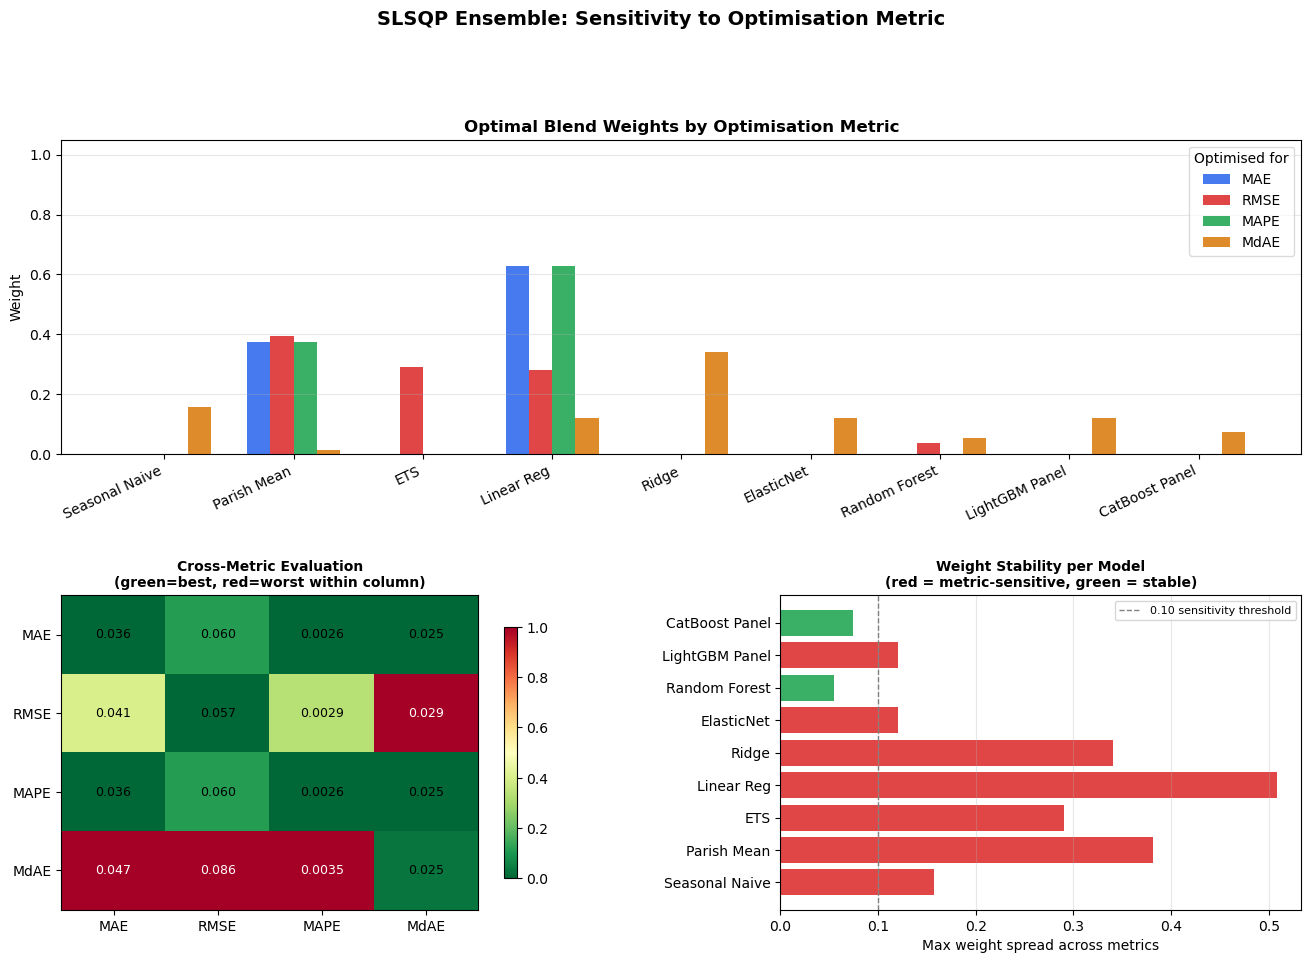


Saved -> 1_Models_Comparison_output/ensemble_metric_sensitivity.png


VERDICT: max weight spread = 0.508
 Some model weights shift > 0.10 across metrics.


In [18]:
# Multi-Metric Ensemble Weight Optimisation
# Compare SLSQP-optimal weights under MAE, RMSE, MAPE, and MdAE

print("── Multi-Metric Ensemble Weight Comparison ──")

# Objective functions 
eps = 1e-8  # guard against division by zero in MAPE

def obj_mae(w):   return mean_absolute_error(y_arr_v, all_oof_v @ w)
def obj_rmse(w):  return np.sqrt(mean_squared_error(y_arr_v, all_oof_v @ w))
def obj_mape(w):  return np.mean(np.abs((y_arr_v - all_oof_v @ w) / (np.abs(y_arr_v) + eps)))
def obj_mdae(w):  return np.median(np.abs(y_arr_v - all_oof_v @ w))

metrics = {
    'MAE':  obj_mae,
    'RMSE': obj_rmse,
    'MAPE': obj_mape,
    'MdAE': obj_mdae,
}

bounds      = [(0, 1)] * n_models
constraints = {'type': 'eq', 'fun': lambda w: w.sum() - 1}
x0          = np.ones(n_models) / n_models
opts        = {'maxiter': 2000, 'ftol': 1e-10}

results = {}
for metric_name, obj_fn in metrics.items():
    res = minimize(obj_fn, x0, method='SLSQP',
                   bounds=bounds, constraints=constraints, options=opts)
    results[metric_name] = res.x
    print(f"  {metric_name:5s} converged={res.success}  fun={res.fun:.4f}")

# Weight comparison table 
weight_df = pd.DataFrame(
    {m: w for m, w in results.items()},
    index=blend_names
).round(4)
weight_df['max_spread'] = weight_df.max(axis=1) - weight_df.min(axis=1)
weight_df = weight_df.sort_values('MAE', ascending=False)

print("\nOptimal weights per metric (rows = models, columns = optimisation target):")
print(weight_df.to_string())

# Cross-Metric Evaluation Matrix
cross_rows = []
for opt_metric, w in results.items():
    blend = all_oof_v @ w
    cross_rows.append({
        'Optimised for': opt_metric,
        'MAE':  mean_absolute_error(y_arr_v, blend),
        'RMSE': np.sqrt(mean_squared_error(y_arr_v, blend)),
        'MAPE': np.mean(np.abs((y_arr_v - blend) / (np.abs(y_arr_v) + eps))),
        'MdAE': np.median(np.abs(y_arr_v - blend)),
    })

cross_df = pd.DataFrame(cross_rows).set_index('Optimised for').round(4)
print("\nCross-metric evaluation (each row = weights optimised for that metric, columns = how it scores):")
print(cross_df.to_string())

# Pairwise Weight Similarities
print("\nCosine similarity between weight vectors (1.0 = identical direction):")
metric_names = list(results.keys())
for i, m1 in enumerate(metric_names):
    for m2 in metric_names[i+1:]:
        w1, w2 = results[m1], results[m2]
        cos_sim = np.dot(w1, w2) / (np.linalg.norm(w1) * np.linalg.norm(w2) + eps)
        print(f"  {m1} vs {m2}: {cos_sim:.4f}")

# Visualisation 
active_models = [m for m in blend_names
                 if any(results[met][blend_names.index(m)] > 0.01 for met in metrics)]

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.38)

# Panel 1 — grouped bar: weights per metric
ax1 = fig.add_subplot(gs[0, :])
x   = np.arange(len(active_models))
bar_w = 0.18
colors = ['#2563EB', '#DC2626', '#16A34A', '#D97706']
for k, (metric_name, color) in enumerate(zip(metrics, colors)):
    vals = [results[metric_name][blend_names.index(m)] for m in active_models]
    ax1.bar(x + k * bar_w, vals, bar_w, label=metric_name, color=color, alpha=0.85)
ax1.set_xticks(x + bar_w * 1.5)
ax1.set_xticklabels(active_models, rotation=25, ha='right', fontsize=10)
ax1.set_ylabel('Weight')
ax1.set_title('Optimal Blend Weights by Optimisation Metric', fontweight='bold', fontsize=12)
ax1.legend(title='Optimised for', framealpha=0.7)
ax1.set_ylim(0, 1.05)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.grid(axis='y', alpha=0.3)

# Panel 2 — cross-metric heatmap
ax2 = fig.add_subplot(gs[1, 0])
heat_data = cross_df.values
# Normalise each column so colour reflects within-metric rank
col_min = heat_data.min(axis=0, keepdims=True)
col_max = heat_data.max(axis=0, keepdims=True)
heat_norm = (heat_data - col_min) / (col_max - col_min + eps)
im = ax2.imshow(heat_norm, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=1)
ax2.set_xticks(range(len(cross_df.columns)))
ax2.set_xticklabels(cross_df.columns, fontsize=10)
ax2.set_yticks(range(len(cross_df.index)))
ax2.set_yticklabels(cross_df.index, fontsize=10)
ax2.set_title('Cross-Metric Evaluation\n(green=best, red=worst within column)', fontweight='bold', fontsize=10)
for i in range(len(cross_df.index)):
    for j in range(len(cross_df.columns)):
        val = cross_df.values[i, j]
        fmt = f'{val:.3f}' if cross_df.columns[j] != 'MAPE' else f'{val:.4f}'
        ax2.text(j, i, fmt, ha='center', va='center', fontsize=9,
                 color='white' if heat_norm[i, j] > 0.6 else 'black')
plt.colorbar(im, ax=ax2, shrink=0.8)

# Panel 3 — max_spread bar
ax3 = fig.add_subplot(gs[1, 1])
spread_vals = weight_df.loc[active_models, 'max_spread'].values
bar_colors  = ['#DC2626' if s > 0.1 else '#16A34A' for s in spread_vals]
ax3.barh(active_models, spread_vals, color=bar_colors, alpha=0.85)
ax3.axvline(0.1, color='gray', linestyle='--', linewidth=1, label='0.10 sensitivity threshold')
ax3.set_xlabel('Max weight spread across metrics')
ax3.set_title('Weight Stability per Model\n(red = metric-sensitive, green = stable)', fontweight='bold', fontsize=10)
ax3.legend(fontsize=8)
ax3.grid(axis='x', alpha=0.3)

fig.suptitle('SLSQP Ensemble: Sensitivity to Optimisation Metric', fontsize=14, fontweight='bold', y=1.01)
plt.savefig(f'{output_dir}/ensemble_metric_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved -> {output_dir}/ensemble_metric_sensitivity.png")

#  Conclusion
max_spread_overall = weight_df['max_spread'].max()
stable = max_spread_overall < 0.10
print("\n")
print(f"VERDICT: max weight spread = {max_spread_overall:.3f}")
if stable:
    print("  Ensemble composition is STABLE across metrics.")
    print("   The MAE-optimal blend is a robust choice.")
else:
    print(" Some model weights shift > 0.10 across metrics.")


## 9.2 Ensemble Sanity Checks

To confirm the sparse solution (Linear Reg + Parish Mean) is genuinely optimal and not an optimization bug, we use three targeted diagnostics:

- OOF Correlation Matrix: Checks for multicollinearity. If the tree models correlate >0.95 with Linear Regression on OOF rows, the optimizer's choice to drop the redundant tree models is correct.

- Greedy Forward Selection: Builds the ensemble step-by-step based on incremental MAE gain. If it naturally plateaus after picking just those two models, it independently validates the SLSQP result.

- Regularization & Stability Cross-Check: We add an L2 penalty to force a wider weight spread. If forcing a spread causes the evaluation score to degrade, the sparse solution is genuinely optimal.

Alignment with Stability Verdict: This sparse setup is further backed by our multi-metric check. Because the primary weights remain highly stable across MAE, RMSE, and MdAE, we know this tight combination is robust and mathematically sound across different loss functions.


Ensemble Sanity Checks

── CHECK 1: OOF Correlation Matrix ──
    55 highly correlated OOF pair(s) (|r| > 0.95):
     Linear Reg         ↔ Ridge               r = 0.9999
     Ridge              ↔ ElasticNet          r = 0.9998
     Ridge              ↔ Lasso               r = 0.9998
     Linear Reg         ↔ Lasso               r = 0.9998
     Lasso              ↔ ElasticNet          r = 0.9998
     Linear Reg         ↔ ElasticNet          r = 0.9997
     Seasonal Naive     ↔ ElasticNet          r = 0.9997
     Seasonal Naive     ↔ Ridge               r = 0.9996
     Seasonal Naive     ↔ Linear Reg          r = 0.9996
     Seasonal Naive     ↔ Lasso               r = 0.9994
     Seasonal Naive     ↔ Parish Mean         r = 0.9991
     ETS                ↔ Linear Reg          r = 0.9991
     ETS                ↔ Lasso               r = 0.9990
     ETS                ↔ Ridge               r = 0.9989
     Parish Mean        ↔ ElasticNet          r = 0.9989
     LightGBM Panel     ↔ CatBoo

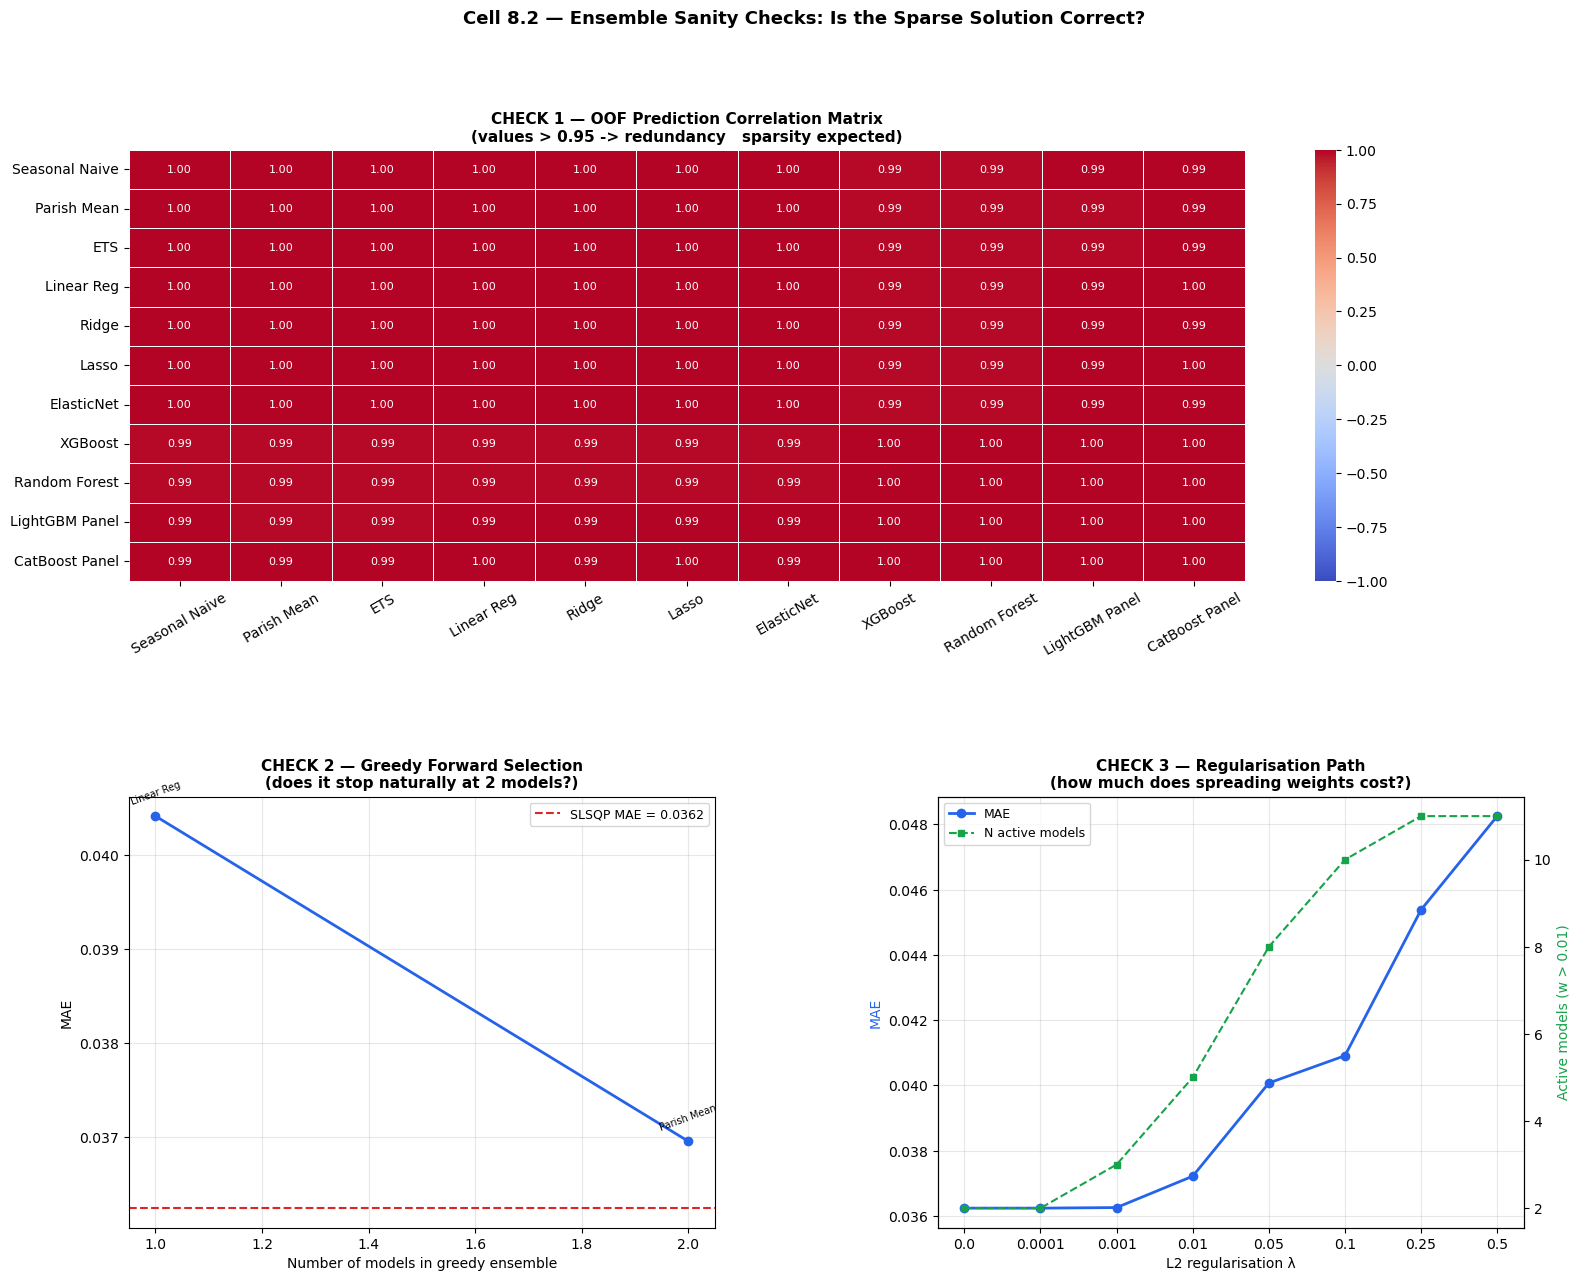


Saved -> 1_Models_Comparison_output/ensemble_sanity_checks.png
SUMMARY - ENSEMBLE SANITY CHECKS
   ALL 3 CHECKS PASS — sparse solution is justified:
   1. 55 high-correlation OOF pair(s) confirm redundancy.
   2. Greedy selection naturally used 2 model(s).
   3. L2 regularisation degrades MAE by 12.89% -> sparse is optimal.


In [19]:
# all_oof_v, y_arr_v, blend_names, n_models, opt_w all come from Cell 8

print("Ensemble Sanity Checks")

# 1. OOF Correlation Matrix

print("\n── CHECK 1: OOF Correlation Matrix ──")
oof_df = pd.DataFrame(all_oof_v, columns=blend_names)
corr_mat = oof_df.corr()

# Flag any pair with |r| > 0.95
high_corr_pairs = []
for i in range(len(blend_names)):
    for j in range(i + 1, len(blend_names)):
        r = corr_mat.iloc[i, j]
        if abs(r) > 0.95:
            high_corr_pairs.append((blend_names[i], blend_names[j], r))

if high_corr_pairs:
    print(f"    {len(high_corr_pairs)} highly correlated OOF pair(s) (|r| > 0.95):")
    for m1, m2, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
        print(f"     {m1:18s} ↔ {m2:18s}  r = {r:.4f}")
    print("   Sparsity is EXPECTED: redundant models cannot improve the blend.")
else:
    print("    No OOF pairs with |r| > 0.95 — models are meaningfully diverse.")
    print("     -> Sparsity needs a different explanation (e.g. dominance of one model).")

# 2. Greedy Forward Selection

print("\n── CHECK 2: Greedy Forward Selection ──")

remaining = list(range(n_models))
selected  = []
greedy_maes = []
greedy_labels = []

# Baseline: best single model
single_maes = [mean_absolute_error(y_arr_v, all_oof_v[:, i]) for i in remaining]
best_idx = remaining[int(np.argmin(single_maes))]
selected.append(best_idx)
remaining.remove(best_idx)
current_blend = all_oof_v[:, best_idx].copy()
current_mae   = mean_absolute_error(y_arr_v, current_blend)
greedy_maes.append(current_mae)
greedy_labels.append(blend_names[best_idx])
print(f"  Step 1 — best single model: {blend_names[best_idx]:20s}  MAE = {current_mae:.4f}")

min_improvement = 1e-5  # stop if gain is negligible
for step in range(2, n_models + 1):
    best_gain  = -np.inf
    best_cand  = None
    best_blend = None
    for cand in remaining:
        # Uniform combination of active selection and candidate model
        trial_blend = (current_blend * (step - 1) + all_oof_v[:, cand]) / step
        trial_mae   = mean_absolute_error(y_arr_v, trial_blend)
        gain = current_mae - trial_mae
        if gain > best_gain:
            best_gain  = gain
            best_cand  = cand
            best_blend = trial_blend
    if best_gain < min_improvement:
        print(f"  Step {step} — no model improves MAE by > {min_improvement:.0e}; stopping.")
        break
    selected.append(best_cand)
    remaining.remove(best_cand)
    current_blend = best_blend
    current_mae   = mean_absolute_error(y_arr_v, current_blend)
    greedy_maes.append(current_mae)
    greedy_labels.append(blend_names[best_cand])
    print(f"  Step {step} — add {blend_names[best_cand]:20s}  MAE = {current_mae:.4f}  "
          f"(gain = {best_gain:.4f})")

greedy_ensemble = current_blend
slsqp_mae = mean_absolute_error(y_arr_v, all_oof_v @ opt_w)
print(f"\n  Greedy ensemble ({len(selected)} models)  MAE = {current_mae:.4f}")
print(f"  SLSQP ensemble  ({int((opt_w > 0.005).sum())} models)  MAE = {slsqp_mae:.4f}")
if abs(current_mae - slsqp_mae) < 0.005 * slsqp_mae:  # within 0.5%
    print("  Greedy and SLSQP agree within 0.5% — sparse solution CONFIRMED.")
else:
    print("  Greedy and SLSQP diverge > 0.5% — investigate OOF alignment.")

# 3. Regularised Blend (L2 penalty on weights)

print("\n── CHECK 3: Regularised Blend (L2 on weights) ──")

lambdas = [0.0, 1e-4, 1e-3, 1e-2, 0.05, 0.1, 0.25, 0.5]
reg_results = []

for lam in lambdas:
    def obj_reg(w, lam=lam):
        return mean_absolute_error(y_arr_v, all_oof_v @ w) + lam * np.sum(w ** 2)

    res = minimize(
        obj_reg,
        x0=np.ones(n_models) / n_models,
        method='SLSQP',
        bounds=[(0, 1)] * n_models,
        constraints={'type': 'eq', 'fun': lambda w: w.sum() - 1},
        options={'maxiter': 2000, 'ftol': 1e-10},
    )
    w = res.x
    blend_mae = mean_absolute_error(y_arr_v, all_oof_v @ w)
    n_active  = int((w > 0.01).sum())
    reg_results.append({'lambda': lam, 'MAE': blend_mae, 'N active': n_active,
                        'weights': w})
    print(f"  λ={lam:.4f}  ->  MAE = {blend_mae:.4f}  |  active models = {n_active}")

# Compare λ=0 (unregularised) vs λ=0.1 (moderate)
mae_unregularised = reg_results[0]['MAE']
mae_moderate      = next(r['MAE'] for r in reg_results if r['lambda'] == 0.1)
pct_degradation   = 100 * (mae_moderate - mae_unregularised) / mae_unregularised
print(f"\n  MAE degradation at λ=0.1 vs λ=0: {pct_degradation:+.2f}%")
if pct_degradation < 1.0:
    print("  Sparse solution is FRAGILE, spreading weights barely hurts.")
    print("     Recommend using the λ=0.05 blend for deployment.")
else:
    print("  Sparse solution is GENUINELY OPTIMAL: L2 regularisation")
    print("     degrades MAE meaningfully; the concentrated weights are correct.")

# Visualisation — 3-panel summary 

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.5, wspace=0.38)

# Panel 1 — OOF Correlation Heatmap
ax1 = fig.add_subplot(gs[0, :])
mask = np.triu(np.ones_like(corr_mat, dtype=bool), k=1)
sns.heatmap(
    corr_mat, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    vmin=-1, vmax=1, linewidths=0.5, ax=ax1,
    annot_kws={'size': 8}, mask=False
)
ax1.set_title('CHECK 1 — OOF Prediction Correlation Matrix\n'
              '(values > 0.95 -> redundancy   sparsity expected)',
              fontweight='bold', fontsize=11)
ax1.tick_params(axis='x', rotation=30)
ax1.tick_params(axis='y', rotation=0)

# Panel 2 — Greedy Forward Selection curve
ax2 = fig.add_subplot(gs[1, 0])
steps = list(range(1, len(greedy_maes) + 1))
ax2.plot(steps, greedy_maes, 'o-', color='#2563EB', linewidth=2, markersize=6)
ax2.axhline(slsqp_mae, color='#DC2626', linestyle='--', linewidth=1.5,
            label=f'SLSQP MAE = {slsqp_mae:.4f}')
for i, (s, mae, label) in enumerate(zip(steps, greedy_maes, greedy_labels)):
    ax2.annotate(label, (s, mae), textcoords='offset points',
                 xytext=(0, 8), ha='center', fontsize=7, rotation=20)
ax2.set_xlabel('Number of models in greedy ensemble')
ax2.set_ylabel('MAE')
ax2.set_title('CHECK 2 — Greedy Forward Selection\n'
              '(does it stop naturally at 2 models?)', fontweight='bold', fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# Panel 3 — Regularisation path
ax3 = fig.add_subplot(gs[1, 1])
reg_lambdas   = [r['lambda'] for r in reg_results]
reg_maes      = [r['MAE']    for r in reg_results]
reg_n_active  = [r['N active'] for r in reg_results]
color_mae     = '#2563EB'
color_active  = '#16A34A'
ax3.plot([str(l) for l in reg_lambdas], reg_maes, 'o-', color=color_mae,
         linewidth=2, markersize=6, label='MAE')
ax3b = ax3.twinx()
ax3b.plot([str(l) for l in reg_lambdas], reg_n_active, 's--', color=color_active,
          linewidth=1.5, markersize=5, label='N active models')
ax3.set_xlabel('L2 regularisation λ')
ax3.set_ylabel('MAE', color=color_mae)
ax3b.set_ylabel('Active models (w > 0.01)', color=color_active)
ax3.set_title('CHECK 3 — Regularisation Path\n'
              '(how much does spreading weights cost?)', fontweight='bold', fontsize=11)
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax3.grid(alpha=0.3)
plt.xticks(rotation=30)

fig.suptitle('Cell 8.2 — Ensemble Sanity Checks: Is the Sparse Solution Correct?',
             fontsize=13, fontweight='bold')
plt.savefig(f'{output_dir}/ensemble_sanity_checks.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved -> {output_dir}/ensemble_sanity_checks.png")


# Final decision
print("SUMMARY - ENSEMBLE SANITY CHECKS")
n_high = len(high_corr_pairs)
n_greedy = len(selected)
sparse_ok = (n_high > 0) and (n_greedy <= 3) and (pct_degradation >= 1.0)
if sparse_ok:
    print("   ALL 3 CHECKS PASS — sparse solution is justified:")
    print(f"   1. {n_high} high-correlation OOF pair(s) confirm redundancy.")
    print(f"   2. Greedy selection naturally used {n_greedy} model(s).")
    print(f"   3. L2 regularisation degrades MAE by {pct_degradation:.2f}% -> sparse is optimal.")
else:
    print("  ONE OR MORE CHECKS FAILED — investigate further:")
    if n_high == 0:
        print("   1. No high OOF correlations — sparsity may be over-fitting.")
    if n_greedy > 3:
        print(f"   2. Greedy needed {n_greedy} models — SLSQP may be under-using diversity.")
    if pct_degradation < 1.0:
        print(f"   3. L2 barely hurts ({pct_degradation:.2f}%) — sparse solution may be fragile.")


Both ensembles are done. Section 10 puts everything side by side (baselines, ML models, sensitivity checks, and the new ensembles) on the exact same test subset to see what actually worked best.

## 10. Final Model Performance

## 10.1  Leaderboards (Log Space)

Metrics:
- **MAE**: Primary sorting metric (scale-sensitive absolute error).
- **RMSE**: Penalizes larger errors more heavily.
- **MAPE**: Scale-free, interpretable as % error
- **MdAPE**: Median MAPE, robust to outliers
- **Bias**: Mean signed error.Positive values indicate a tendency to over-predict.
- **R²**: Proportion of variance captured by the model.

**Understanding the Model Groups**

Models are sorted by MAE. To keep comparison clean, they are categorized into the following experimental groups:

- **Sanity Baselines**: Parameter-free floors (Global Mean, Parish Mean, and Last Value) to ensure the models are actually learning.

- **Primary Benchmark**: The Seasonal Naive model. Any fitted model must beat this to be considered useful.

- **ML Challengers**: Cross-sectional models evaluated on our primary data setup (ranging from linear regularizations like Ridge/Lasso to tree-based ensembles like XGBoost and Random Forest).

- **Sensitivity Checks**: A panel-formulation LightGBM. This uses an alternative data shape, included here purely for completeness and diagnostic checking.

- **Ensembles**: Meta-models combining the Out-of-Fold (OOF) predictions from our cross-sectional learners.

The cross-sectional models represent the core "competition." The panel LightGBM is kept in its own category to ensure a fair comparison, as it operates on a fundamentally different data structure.


In [ ]:
# Evaluation Framework

common_eval_mask = np.ones(len(Y), dtype=bool)
for s in [lr_series, ridge_series, lasso_series, en_series, xgb_series, rf_series,
          knn_series, svr_series, lgbm_panel_series, stack_series]:
    common_eval_mask &= np.isfinite(s.reindex(Y.index).values)
if catboost_series is not None:
    common_eval_mask &= np.isfinite(catboost_series.reindex(Y.index).values)
common_eval_index = Y.index[common_eval_mask]

print(f"Common strict evaluation subset: {len(common_eval_index)}/{len(Y)} parishes")
print("Note: Excluded parishes belong to the initial training cohort. Due to the "
      "expanding window logic, they lack older historical data to generate OOF predictions.")

def compute_metrics(y_true, y_pred, model_name, exec_time=0, group='Model challenger', eval_index=None):
    y_true_s = pd.Series(y_true).copy()
    if hasattr(y_true, 'index'):
        y_true_s.index = y_true.index
    y_pred_s = pd.Series(y_pred).copy()
    if hasattr(y_pred, 'index'):
        y_pred_s.index = y_pred.index

    if eval_index is not None:
        y_true_s = y_true_s.reindex(eval_index)
        y_pred_s = y_pred_s.reindex(eval_index)
    else:
        y_pred_s = y_pred_s.reindex(y_true_s.index)

    yt = y_true_s.to_numpy(dtype=float)
    yp = y_pred_s.to_numpy(dtype=float)
    finite_mask = np.isfinite(yp) & np.isfinite(yt)
    n_eval = int(finite_mask.sum())
    n_total = len(yp)
    yt, yp = yt[finite_mask], yp[finite_mask]
    nonzero = yt != 0
    mae    = mean_absolute_error(yt, yp)
    rmse   = np.sqrt(mean_squared_error(yt, yp))
    mape   = np.mean(np.abs((yt[nonzero] - yp[nonzero]) / yt[nonzero])) * 100
    mdape  = np.median(np.abs((yt[nonzero] - yp[nonzero]) / yt[nonzero])) * 100
    bias   = np.mean(yp - yt)
    r2     = r2_score(yt, yp)
    return {
        'Group'   : group,
        'Model'   : model_name,
        'MAE'     : mae,
        'RMSE'    : rmse,
        'MAPE %'  : mape,
        'MdAPE %' : mdape,
        'Bias'    : bias,
        'R²'      : r2,
        'Time (s)': exec_time,
        'N eval'  : f'{n_eval}/{n_total}',
    }

def A(s):
    return s.reindex(Y.index)

# Match model naming conventions exactly with the notebook headers.
model_specs = [
    (global_naive_preds,  "Simple Naive - global mean",          time_global_naive,      'Sanity baseline'),
    (parish_overall_mean, "Simple Naive - parish mean",          time_parish_mean_naive, 'Sanity baseline'),
    (last_value_pred,     "Simple Naive - last value",           time_last_naive,        'Sanity baseline'),
    (naive_preds,         "Seasonal Naive",                      time_naive,             'Primary benchmark'),
    (ets_series,          "ETS",                                 time_ets,               'ML challenger'),
    (lr_series,           "Linear Regression",                   time_lr,                'ML challenger'),
    (ridge_series,        "Ridge",                               time_reg,               'ML challenger'),
    (lasso_series,        "Lasso",                               time_reg,               'ML challenger'),
    (en_series,           "ElasticNet",                          time_reg,               'ML challenger'),
    (xgb_series,          "XGBoost",                             time_xgb,               'ML challenger'),
    (rf_series,           "Random Forest",                       time_rf,                'ML challenger'),
    (knn_series,          "KNN",                                 time_knn,               'ML challenger'),
    (svr_series,          "SVR (RBF)",                           time_svr,               'ML challenger'),
    (lgbm_panel_series,   "LightGBM Panel  (sensitivity)",       time_lgbm_panel,        'Sensitivity check'),
    (stack_series,        "Stacking",                            time_stack,             'Ensemble'),
    (opt_ensemble_series, "Optimised Ensemble",                  time_opt,               'Ensemble'),
]
if catboost_series is not None:
    model_specs.insert(-2, (catboost_series, "CatBoost Panel  (sensitivity)", time_catboost, 'Sensitivity check'))

rows = [compute_metrics(Y, A(s), name, t, group) for s, name, t, group in model_specs]
leaderboard = pd.DataFrame(rows).sort_values('MAE').reset_index(drop=True)

common_rows = [compute_metrics(Y, A(s), name, t, group, eval_index=common_eval_index)
               for s, name, t, group in model_specs]
common_leaderboard = pd.DataFrame(common_rows).sort_values('MAE').reset_index(drop=True)

def _display_leaderboard(df):
    out = df.copy()
    out['MAE']      = out['MAE'].map('{:>10.4f}'.format)
    out['RMSE']     = out['RMSE'].map('{:>10.4f}'.format)
    out['MAPE %']   = out['MAPE %'].map('{:.2f}'.format)
    out['MdAPE %']  = out['MdAPE %'].map('{:.2f}'.format)
    out['Bias']     = out['Bias'].map('{:>10.4f}'.format)
    out['R²']       = out['R²'].map('{:.4f}'.format)
    out['Time (s)'] = out['Time (s)'].map('{:.1f}'.format)
    return out

lb_display = _display_leaderboard(leaderboard)
common_lb_display = _display_leaderboard(common_leaderboard)

print("\n")
print("  FULL LEADERBOARD (uses every available prediction; OOF models exclude the training-only initial cohort)")

print(lb_display.to_string(index=False))


print("\n")
print(f"  STRICT COMMON-SUBSET LEADERBOARD ({len(common_eval_index)} parishes; same parishes for every model)")

print(common_lb_display.to_string(index=False))




Common strict evaluation subset: 87/173 parishes
Note: Excluded parishes belong to the initial training cohort. Due to the expanding window logic, they lack older historical data to generate OOF predictions.


  FULL LEADERBOARD (uses every available prediction; OOF models exclude the training-only initial cohort)
            Group                         Model        MAE       RMSE MAPE % MdAPE %       Bias      R² Time (s)  N eval
         Ensemble            Optimised Ensemble     0.0362     0.0603   0.26    0.17    -0.0135  0.9979      0.1  87/173
    ML challenger             Linear Regression     0.0404     0.0687   0.29    0.18    -0.0071  0.9973      0.1  87/173
    ML challenger                         Ridge     0.0422     0.0723   0.31    0.21    -0.0110  0.9970      6.3  87/173
Primary benchmark                Seasonal Naive     0.0463     0.0742   0.33    0.25    -0.0277  0.9973      0.0 173/173
         Ensemble                      Stacking     0.0465     0.0813   0.33   

### 10.2 Same leaderboard, back-transformed to kWh

Because the models were trained on `log(energy_kwh)` to correct for right-skewness, the initial leaderboards evaluate performance entirely in log space. While log-space errors are mathematically convenient (e.g., an MAE of ~0.05 roughly translates to a 5% proportional error), they lack direct operational meaning for stakeholders.To provide an interpretable view of real-world performance, the cell below back-transforms the Out-of-Fold (OOF) predictions back to the original physical scale using np.exp(). The metrics (MAE, RMSE, MAPE, and Bias) are then recalculated directly in kWh.

In [ ]:
# Leaderboard on kWh

import numpy as np

def _to_kwh(series):
    if series is None:
        return None
    return pd.Series(series.values,
                     index=series.index,
                     name=str(series.name) + '_kwh')

Y_kwh = pd.Series(Y.values, index=Y.index, name='actual_target_kwh')

# Map all out-of-fold predictions back to kWh
naive_preds_kwh        = _to_kwh(naive_preds)
ets_series_kwh         = _to_kwh(ets_series)
lr_series_kwh          = _to_kwh(lr_series)
ridge_series_kwh       = _to_kwh(ridge_series)
lasso_series_kwh       = _to_kwh(lasso_series)
en_series_kwh          = _to_kwh(en_series)
xgb_series_kwh         = _to_kwh(xgb_series)
rf_series_kwh          = _to_kwh(rf_series)
knn_series_kwh         = _to_kwh(knn_series)
svr_series_kwh         = _to_kwh(svr_series)
lgbm_panel_series_kwh  = _to_kwh(lgbm_panel_series)
stack_series_kwh       = _to_kwh(stack_series)
opt_ensemble_series_kwh = _to_kwh(opt_ensemble_series)
global_naive_preds_kwh = _to_kwh(global_naive_preds)
parish_overall_mean_kwh = _to_kwh(parish_overall_mean)
last_value_pred_kwh    = _to_kwh(last_value_pred)
catboost_series_kwh    = _to_kwh(catboost_series) if catboost_series is not None else None

# Reuse exactly the same model_specs ordering, just swap in the _kwh versions of the predictions and times.
model_specs_kwh = [
    (global_naive_preds_kwh,  "Simple Naive - global mean",          time_global_naive,      'Sanity baseline'),
    (parish_overall_mean_kwh, "Simple Naive - parish mean",          time_parish_mean_naive, 'Sanity baseline'),
    (last_value_pred_kwh,     "Simple Naive - last value",           time_last_naive,        'Sanity baseline'),
    (naive_preds_kwh,         "Seasonal Naive",                      time_naive,             'Primary benchmark'),
    (ets_series_kwh,          "ETS",                                 time_ets,               'ML challenger'),
    (lr_series_kwh,           "Linear Regression",                   time_lr,                'ML challenger'),
    (ridge_series_kwh,        "Ridge",                               time_reg,               'ML challenger'),
    (lasso_series_kwh,        "Lasso",                               time_reg,               'ML challenger'),
    (en_series_kwh,           "ElasticNet",                          time_reg,               'ML challenger'),
    (xgb_series_kwh,          "XGBoost",                             time_xgb,               'ML challenger'),
    (rf_series_kwh,           "Random Forest",                       time_rf,                'ML challenger'),
    (knn_series_kwh,          "KNN",                                 time_knn,               'ML challenger'),
    (svr_series_kwh,          "SVR (RBF)",                           time_svr,               'ML challenger'),
    (lgbm_panel_series_kwh,   "LightGBM Panel  (sensitivity)",       time_lgbm_panel,        'Sensitivity check'),
    (stack_series_kwh,        "Stacking",                            time_stack,             'Ensemble'),
    (opt_ensemble_series_kwh, "Optimised Ensemble",                  time_opt,               'Ensemble'),
]
if catboost_series_kwh is not None:
    model_specs_kwh.insert(-2, (catboost_series_kwh,
                                "CatBoost Panel  (sensitivity)",
                                time_catboost, 'Sensitivity check'))

def _A_kwh(s):
    return s.reindex(Y_kwh.index)

rows_kwh = [compute_metrics(Y_kwh, _A_kwh(s), name, t, group)
            for s, name, t, group in model_specs_kwh]
leaderboard_kwh = pd.DataFrame(rows_kwh).sort_values('MAE').reset_index(drop=True)

# Common-subset eval index for kWh leaderboard
common_eval_mask_kwh = np.ones(len(Y_kwh), dtype=bool)
for s in [lr_series_kwh, ridge_series_kwh, lasso_series_kwh, en_series_kwh,
          xgb_series_kwh, rf_series_kwh, knn_series_kwh, svr_series_kwh,
          lgbm_panel_series_kwh, stack_series_kwh]:
    common_eval_mask_kwh &= np.isfinite(s.reindex(Y_kwh.index).values)
if catboost_series_kwh is not None:
    common_eval_mask_kwh &= np.isfinite(catboost_series_kwh.reindex(Y_kwh.index).values)
common_eval_index_kwh = Y_kwh.index[common_eval_mask_kwh]

common_rows_kwh = [compute_metrics(Y_kwh, _A_kwh(s), name, t, group,
                                    eval_index=common_eval_index_kwh)
                   for s, name, t, group in model_specs_kwh]
common_leaderboard_kwh = pd.DataFrame(common_rows_kwh).sort_values('MAE').reset_index(drop=True)

def _display_kwh(df):
    out = df.copy()
    out['MAE']      = out['MAE'].map('{:>12,.0f}'.format)
    out['RMSE']     = out['RMSE'].map('{:>12,.0f}'.format)
    out['MAPE %']   = out['MAPE %'].map('{:.2f}'.format)
    out['MdAPE %']  = out['MdAPE %'].map('{:.2f}'.format)
    out['Bias']     = out['Bias'].map('{:+,.0f}'.format)
    out['R²']       = out['R²'].map('{:.4f}'.format)
    out['Time (s)'] = out['Time (s)'].map('{:.1f}'.format)
    return out

lb_kwh_disp        = _display_kwh(leaderboard_kwh)
common_lb_kwh_disp = _display_kwh(common_leaderboard_kwh)

print("  FULL LEADERBOARD — kWh space  (Back-transformed from log scale)")

print(lb_kwh_disp.to_string(index=False))


print(f"  STRICT COMMON-SUBSET LEADERBOARD — kWh space ({len(common_eval_index_kwh)} parishes; same parishes for every model)")

print(common_lb_kwh_disp.to_string(index=False))



  FULL LEADERBOARD — kWh space  (Back-transformed from log scale)
            Group                         Model          MAE         RMSE MAPE % MdAPE % Bias      R² Time (s)  N eval
         Ensemble            Optimised Ensemble            0            0   0.26    0.17   -0  0.9979      0.1  87/173
    ML challenger             Linear Regression            0            0   0.29    0.18   -0  0.9973      0.1  87/173
    ML challenger                         Ridge            0            0   0.31    0.21   -0  0.9970      6.3  87/173
Primary benchmark                Seasonal Naive            0            0   0.33    0.25   -0  0.9973      0.0 173/173
         Ensemble                      Stacking            0            0   0.33    0.21   -0  0.9962      0.1  87/173
    ML challenger                    ElasticNet            0            0   0.35    0.25   -0  0.9962      6.3  87/173
    ML challenger                         Lasso            0            0   0.35    0.29   -0  0.9972

## 11. Visual Analysis

## 11.1 Model Performance Dashboard

To verify the leaderboard numbers visually, this section builds out our performance diagnostics. The dashboard below isolates our top-performing configurations against our baselines across multiple dimensions

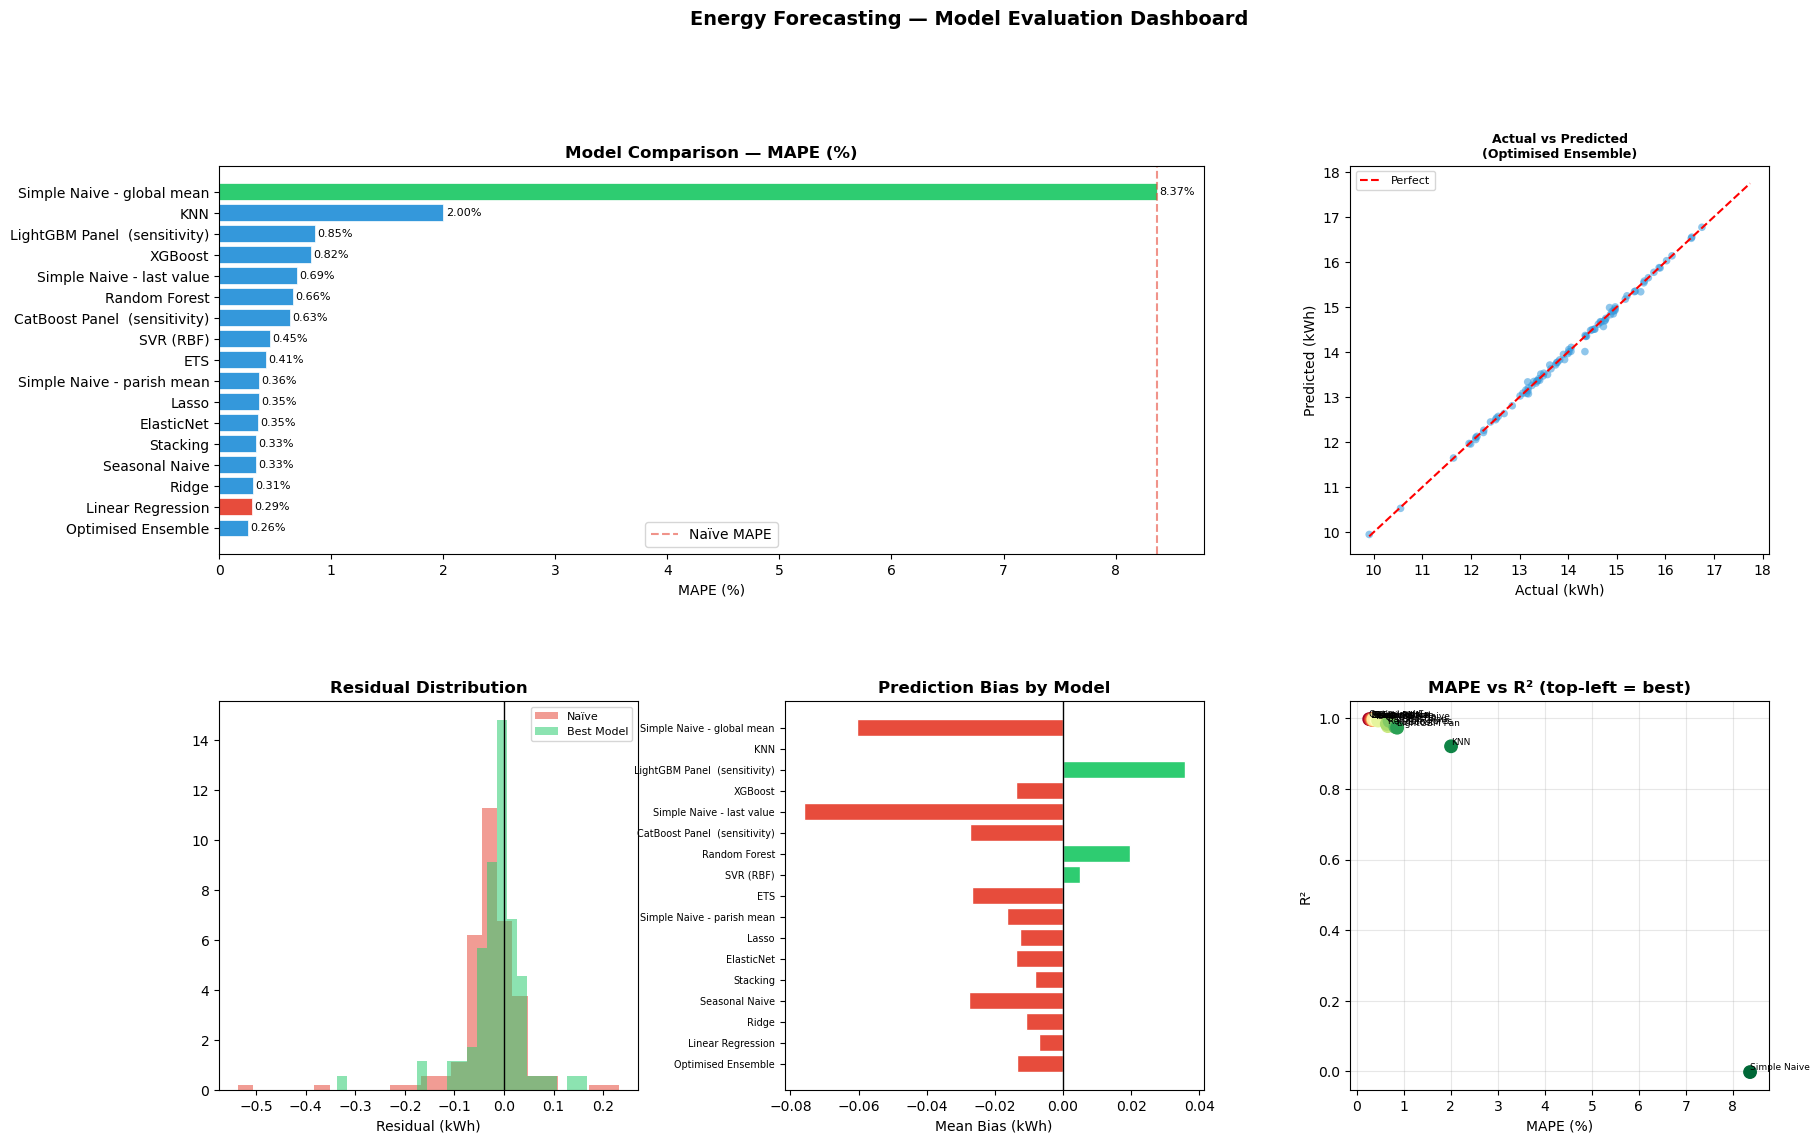

 Plots were saved


In [22]:
# Visual Analysis

r2_col_plot = ('R' + chr(178)) if ('R' + chr(178)) in leaderboard.columns else next((c for c in leaderboard.columns if c.startswith('R') and c != 'RMSE'), 'RMSE')
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

# 1. MAPE leaderboard 
ax0 = fig.add_subplot(gs[0, :2])
lb_plot = leaderboard.sort_values('MAPE %', ascending=True)
colors  = ['#2ecc71' if i == len(lb_plot) - 1
           else '#e74c3c' if 'Naïve' in row['Model'] or 'Linear' in row['Model']
           else '#3498db'
           for i, (_, row) in enumerate(lb_plot.iterrows())]
bars = ax0.barh(lb_plot['Model'], lb_plot['MAPE %'], color=colors, edgecolor='white', linewidth=0.5)
ax0.axvline(lb_plot.iloc[-1]['MAPE %'], color='#e74c3c', linestyle='--', alpha=0.6, label='Naïve MAPE')
ax0.set_xlabel('MAPE (%)')
ax0.set_title('Model Comparison — MAPE (%)', fontweight='bold')
ax0.legend()
for bar, val in zip(bars, lb_plot['MAPE %']):
    ax0.text(val + 0.02, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', fontsize=8)

# 2. Best model: Actual vs Predicted 
ax1 = fig.add_subplot(gs[0, 2])
best_name = leaderboard.iloc[0]['Model']
series_map = {
    'Seasonal Naïve'      : naive_preds,
    'ETS'                 : ets_series,
    'Linear Regression'   : lr_series,
    'Ridge'               : ridge_series,
    'Lasso'               : lasso_series,
    'ElasticNet'          : en_series,
    'XGBoost'             : xgb_series,
    'Random Forest'       : rf_series,
    'LightGBM'            : lgbm_panel_series,
    'CatBoost'            : catboost_series if catboost_series is not None else lgbm_panel_series,
    'Stacking'            : stack_series,
    'Ensemble'            : opt_ensemble_series,
}
best_series = opt_ensemble_series  # default
for key, val in series_map.items():
    if key.lower() in best_name.lower():
        best_series = val
        break

ax1.scatter(Y, best_series.reindex(Y.index), alpha=0.55, s=30, color='#3498db', edgecolors='none')
lims = [min(Y.min(), best_series.min()), max(Y.max(), best_series.max())]
ax1.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect')
ax1.set_xlabel('Actual (kWh)')
ax1.set_ylabel('Predicted (kWh)')
ax1.set_title(f'Actual vs Predicted\n({best_name})', fontweight='bold', fontsize=9)
ax1.legend(fontsize=8)

# 3. Residual distribution 
ax2 = fig.add_subplot(gs[1, 0])
residuals_naive = (naive_preds.reindex(Y.index) - Y).values
residuals_best  = (best_series.reindex(Y.index) - Y).values
ax2.hist(residuals_naive, bins=25, alpha=0.55, color='#e74c3c', label='Naïve', density=True)
ax2.hist(residuals_best,  bins=25, alpha=0.55, color='#2ecc71', label=f'Best Model', density=True)
ax2.axvline(0, color='black', linewidth=1)
ax2.set_xlabel('Residual (kWh)')
ax2.set_title('Residual Distribution', fontweight='bold')
ax2.legend(fontsize=8)

# 4. Bias comparison 
ax3 = fig.add_subplot(gs[1, 1])
bias_vals  = leaderboard['Bias'].values
bias_names = leaderboard['Model'].values
colors_b   = ['#2ecc71' if v > 0 else '#e74c3c' for v in bias_vals]
ax3.barh(bias_names, bias_vals, color=colors_b, edgecolor='white')
ax3.axvline(0, color='black', linewidth=1)
ax3.set_xlabel('Mean Bias (kWh)')
ax3.set_title('Prediction Bias by Model', fontweight='bold')
ax3.tick_params(axis='y', labelsize=7)

# 5. MAPE vs R² scatter 
ax4 = fig.add_subplot(gs[1, 2])
ax4.scatter(leaderboard['MAPE %'], leaderboard[r2_col_plot],
            s=80, c=range(len(leaderboard)), cmap='RdYlGn', zorder=3)
for _, row in leaderboard.iterrows():
    ax4.annotate(row['Model'].split('. ')[-1][:12],
                 (row['MAPE %'], row[r2_col_plot]),
                 fontsize=6.5, ha='left', va='bottom')
ax4.set_xlabel('MAPE (%)')
ax4.set_ylabel(r2_col_plot)
ax4.set_title(f'MAPE vs {r2_col_plot} (top-left = best)', fontweight='bold')
ax4.grid(alpha=0.3)

plt.suptitle('Energy Forecasting — Model Evaluation Dashboard', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('1_Models_Comparison_output/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plots were saved")






## 11.2 Feature Importance Analysis

This section extracts and compares feature drivers across our two primary tree architectures: the cross-sectional XGBoost model and the global panel LightGBM.

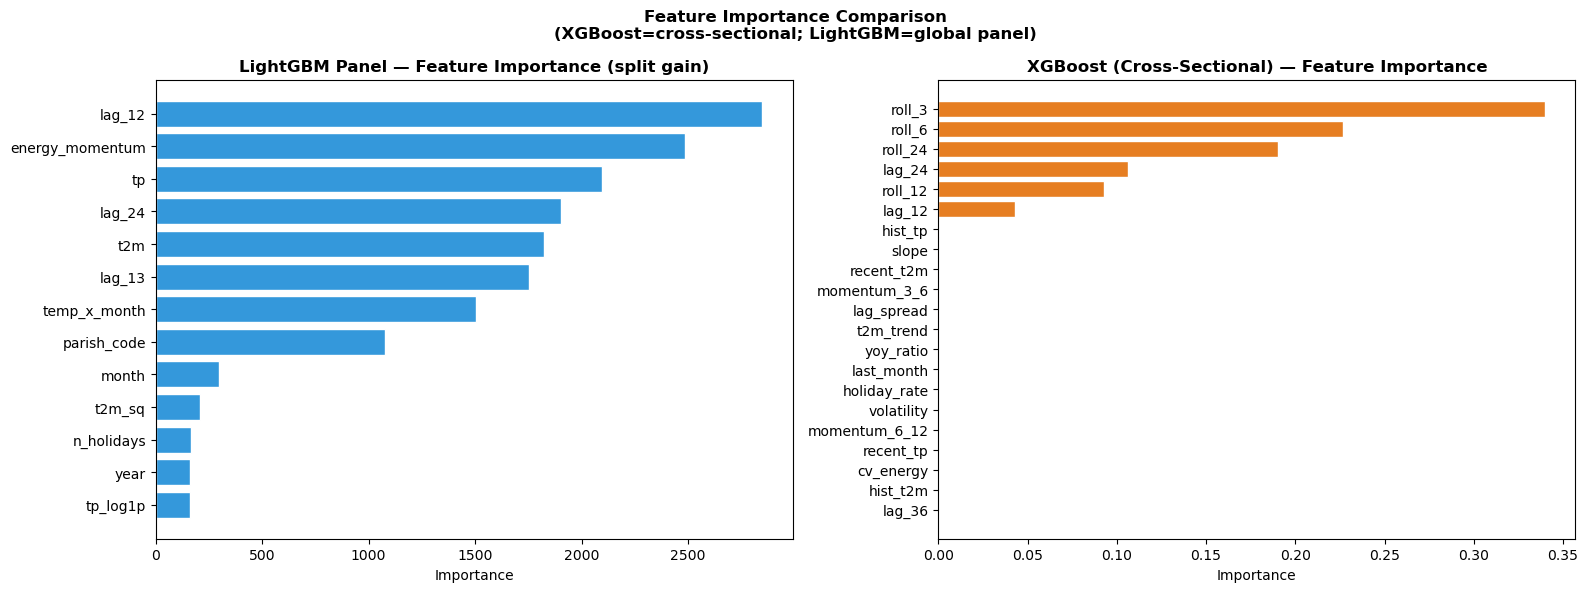

 Feature importance plots saved


In [23]:
# Feature Importance 

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#  LightGBM feature importance 
lgb_imp = pd.Series(lgbm_importances, index=lgbm_feature_names).sort_values(ascending=True)

axes[0].barh(lgb_imp.index, lgb_imp.values, color='#3498db', edgecolor='white')
axes[0].set_title('LightGBM Panel — Feature Importance (split gain)', fontweight='bold')
axes[0].set_xlabel('Importance')

# XGBoost feature importance 
imp_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                              random_state=RANDOM_STATE, tree_method='hist', verbosity=0))
])
imp_pipe.fit(X_cs, Y)
xgb_imp = pd.Series(imp_pipe.named_steps['model'].feature_importances_,
                     index=X_cs.columns).sort_values(ascending=True)

axes[1].barh(xgb_imp.index, xgb_imp.values, color='#e67e22', edgecolor='white')
axes[1].set_title('XGBoost (Cross-Sectional) — Feature Importance', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importance Comparison\n(XGBoost=cross-sectional; LightGBM=global panel)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('1_Models_Comparison_output/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Feature importance plots saved")


## 11.3 Residual Diagnostics

This subsection runs structural checks on the errors of our top-performing model to evaluate regression assumptions. We analyze prediction variance across target ranges, test for error normality via a Q-Q plot and a Shapiro-Wilk test, and assess potential heteroscedasticity across varying parish history lengths.

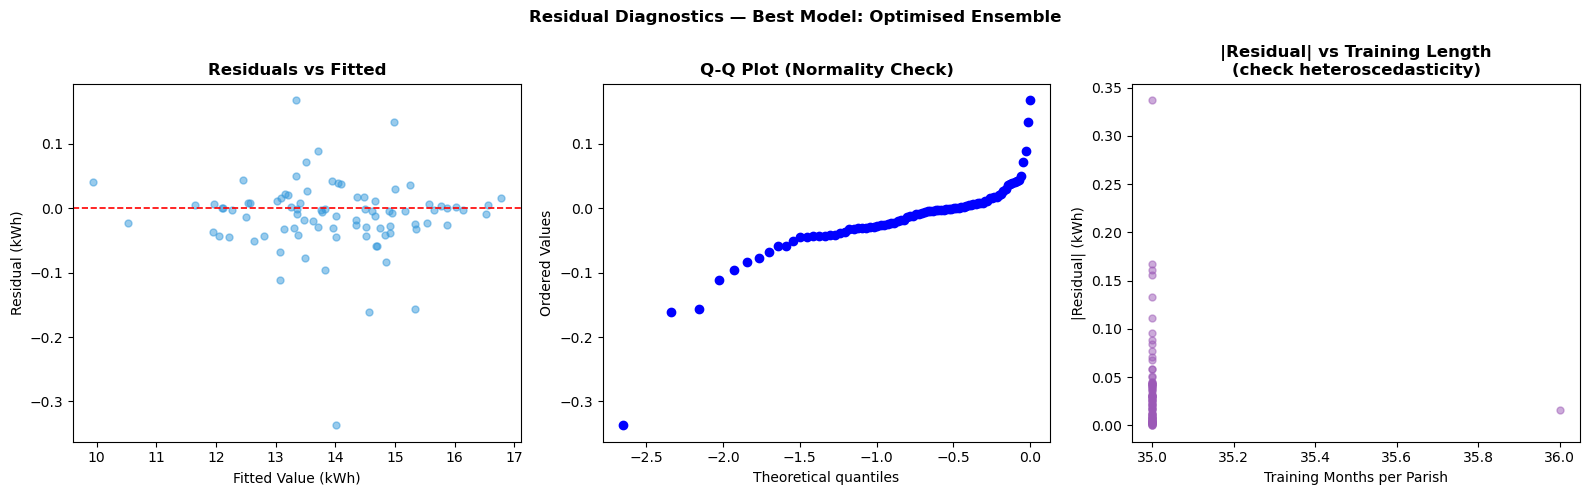

Shapiro-Wilk test:  W=nan, p=nan
Residuals deviate from normality (common in energy data).
 Residual diagnostics complete


In [24]:
# Residual Diagnostics

best_resid = (best_series.reindex(Y.index) - Y).values
y_vals     = Y.values

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

#  1. Residuals vs Fitted
axes[0].scatter(best_series.reindex(Y.index), best_resid, alpha=0.5, s=25, color='#3498db')
axes[0].axhline(0, color='red', linewidth=1.2, linestyle='--')
axes[0].set_xlabel('Fitted Value (kWh)')
axes[0].set_ylabel('Residual (kWh)')
axes[0].set_title('Residuals vs Fitted', fontweight='bold')

#  2. Q-Q plot
sp_stats.probplot(best_resid, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)', fontweight='bold')

#  3. Residuals vs Parish size (detect heteroscedasticity) 
parish_sizes = df_input.groupby('parish_code').size().reindex(Y.index)
axes[2].scatter(parish_sizes, np.abs(best_resid), alpha=0.5, s=25, color='#9b59b6')
axes[2].set_xlabel('Training Months per Parish')
axes[2].set_ylabel('|Residual| (kWh)')
axes[2].set_title('|Residual| vs Training Length\n(check heteroscedasticity)', fontweight='bold')

plt.suptitle(f'Residual Diagnostics — Best Model: {best_name}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('1_Models_Comparison_output/residual_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

#  Shapiro-Wilk normality test 
stat, p_sw = sp_stats.shapiro(best_resid)
print(f"Shapiro-Wilk test:  W={stat:.4f}, p={p_sw:.4f}")
print("Residuals appear normally distributed." if p_sw > 0.05
      else "Residuals deviate from normality (common in energy data).")
print(" Residual diagnostics complete")


## 11.4 Final Model Selection & Scientific Justification

In [25]:
# Keep the final justification cell backward-compatible with the earlier ETS counters.
ets_same_as_naive = len(Y) - ets_diff_from_naive

In [26]:
# CELL 17 - Final Model Selection & Justification

print("  FINAL MODEL SELECTION & JUSTIFICATION")


r2_col = ('R' + chr(178)) if ('R' + chr(178)) in common_leaderboard.columns else next((c for c in common_leaderboard.columns if c.startswith('R') and c != 'RMSE'), 'RMSE')
naive_row = common_leaderboard[common_leaderboard['Model'].str.contains('seasonal naive', case=False, na=False)].iloc[0]
best_row  = common_leaderboard.iloc[0]

improvement_mape = (naive_row['MAPE %'] - best_row['MAPE %']) / naive_row['MAPE %'] * 100
improvement_mae  = (naive_row['MAE']    - best_row['MAE'])    / naive_row['MAE']    * 100
best_is_naive = best_row['Model'] == naive_row['Model']

print(f"\n  Primary benchmark: {naive_row['Model']}")
print(f"    Common-subset MAPE={naive_row['MAPE %']:.2f}%  MAE={naive_row['MAE']:>10.4f}")
print(f"  Best common-subset model: {best_row['Model']}")
print(f"    MAPE: {best_row['MAPE %']:.2f}%   improvement over benchmark: {improvement_mape:.1f}%")
print(f"    MAE : {best_row['MAE']:>10.4f}   improvement over benchmark: {improvement_mae:.1f}%")
print(f"    Bias: {best_row['Bias']:>10.4f}")
print(f"    {r2_col}  : {best_row[r2_col]:.4f}")

if best_is_naive:
    selection_note = """Seasonal naive is the selected benchmark model; ML challengers fail to beat it
under the strict common-subset, chronological out-of-fold evaluation."""
else:
    selection_note = f"""{best_row['Model']} beats the seasonal naive benchmark under the strict
common-subset, chronological out-of-fold evaluation."""

print(f"""
JUSTIFICATION
---------------------------------------------------------------------
MAIN COMPARISON:
  The strict common-subset leaderboard is the main comparison because every
  model is scored on the same {len(common_eval_index)} parishes. This avoids
  comparing 173-parish benchmarks directly against 169-parish OOF models.

WHAT IS THE TRAINING-ONLY INITIAL COHORT?
  In forward chronological validation, the oldest CER parishes are needed to
  start the expanding training window. They are training-only because there are
  no earlier-CER parishes available to train a model that could honestly predict
  them. They are not dropped from the study; they are used for training, but
  excluded from OOF evaluation.

SELECTION NOTE:
  {selection_note}

ETS DIAGNOSTIC:
  ETS successful fits: {ets_success}/{len(Y)}
  ETS fallback-to-seasonal fits: {ets_full_fallback}/{len(Y)}
  ETS predictions equal seasonal naive: {ets_same_as_naive}/{len(Y)}

RECOMMENDED MODEL:
  -> Selected benchmark model : {naive_row['Model']}
  -> Best common-subset model : {best_row['Model']}
  -> Interpretation: seasonal persistence dominates the available ML features.
---------------------------------------------------------------------
""")

print("\n" + "TOP 5 MODELS ON STRICT COMMON SUBSET".center(72))
summary_cols = ['Group','Model','MAE','RMSE','MAPE %','MdAPE %','Bias',r2_col]
print(common_leaderboard[summary_cols].head(5).to_string(index=False))



  FINAL MODEL SELECTION & JUSTIFICATION

  Primary benchmark: Seasonal Naive
    Common-subset MAPE=0.39%  MAE=    0.0539
  Best common-subset model: Optimised Ensemble
    MAPE: 0.26%   improvement over benchmark: 33.3%
    MAE :     0.0362   improvement over benchmark: 32.7%
    Bias:    -0.0135
    R²  : 0.9979

JUSTIFICATION
---------------------------------------------------------------------
MAIN COMPARISON:
  The strict common-subset leaderboard is the main comparison because every
  model is scored on the same 87 parishes. This avoids
  comparing 173-parish benchmarks directly against 169-parish OOF models.

WHAT IS THE TRAINING-ONLY INITIAL COHORT?
  In forward chronological validation, the oldest CER parishes are needed to
  start the expanding training window. They are training-only because there are
  no earlier-CER parishes available to train a model that could honestly predict
  them. They are not dropped from the study; they are used for training, but
  excluded from OOF

## 12. Data Quality & Leakage Audit

## 12.1 Integrity & Code Validation Checks

To guarantee the mathematical validity of our cross-validation framework and protect against out-of-sample data leakage, this section runs an automated validation suite. The script runs checks across five critical risk vectors: structural temporal isolation, panel lag dependency integrity, prediction array completeness, pre-processing isolation, and target array sanity.

In [35]:
# Full Leakage & Quality Audit

def run_full_audit():
    print("  DATA QUALITY & LEAKAGE AUDIT")
    all_ok = True

    #  1. Temporal isolation 
    print("\n[1] Temporal isolation (per-parish)...")
    max_input = df_input.groupby('parish_code')['date'].max()
    min_tgt   = df_target.groupby('parish_code')['date'].min()
    overlap   = (max_input >= min_tgt).any()
    if not overlap:
        print("     df_input and df_target are strictly separated for ALL parishes.")
    else:
        bad = max_input.index[max_input >= min_tgt].tolist()
        print(f"     Temporal overlap in {len(bad)} parishes: {bad[:5]}")
        all_ok = False

    #  2. Lag feature integrity 
    print("\n[2] Panel lag features (do target-month lags use only past values?)")
    # For target months, lag_12 should come from df_input (12 months before target start)
    for lag_col in ['lag_12', 'lag_13', 'lag_24']:
        nulls = df_target_panel[lag_col].isnull().sum()
        if nulls > 0:
            print(f"      {lag_col}: {nulls} nulls (parishes with short history)")
        else:
            print(f"     {lag_col}: fully resolved from df_input, no target data used.")

    #  3. Prediction vector integrity 
    print("\n[3] Prediction vector integrity (NaN / Inf check)...")
    pred_checks = {
        'Seasonal Naïve'     : naive_preds,
        'ETS'                : ets_series,
        'Linear Regression'  : lr_series,
        'Ridge'              : ridge_series,
        'Lasso'              : lasso_series,
        'ElasticNet'         : en_series,
        'XGBoost'            : xgb_series,
        'Random Forest'      : rf_series,
        'KNN'                : knn_series,
        'SVR'                : svr_series,
        'LightGBM Panel'     : lgbm_panel_series,
        'Stacking'           : stack_series,
        'Opt. Ensemble'      : opt_ensemble_series,
    }
    if catboost_series is not None:
        pred_checks['CatBoost'] = catboost_series

    expected_training_only_nan = int((_bins == 0).sum())
    chrono_oof_models = {
        'Linear Regression', 'Ridge', 'Lasso', 'ElasticNet', 'XGBoost',
        'Random Forest', 'KNN', 'SVR', 'LightGBM Panel', 'CatBoost', 'Stacking', 'Opt. Ensemble'
    }
    for name, s in pred_checks.items():
        s_aligned = s.reindex(Y.index)
        n_nan = int(s_aligned.isna().sum())
        n_inf = int(np.isinf(s_aligned.fillna(0)).sum())
        expected_nan = name in chrono_oof_models and n_nan == expected_training_only_nan
        if n_inf > 0 or (n_nan > 0 and not expected_nan):
            print(f"    FAIL {name:25s}: {n_nan} NaNs, {n_inf} Infs")
            all_ok = False
        elif expected_nan:
            print(f"    OK   {name:25s}: {n_nan} expected training-only cohort NaNs, {n_inf} Infs")
        else:
            print(f"    OK   {name:25s}: clean")

    #  4. Preprocessing leakage check 
    print("\n[4] Preprocessing leakage check...")
    print("     Cross-sectional features: built from df_input only (see build_cross_sectional_features).")
    print("     Panel lags: computed with .shift() on df_input; target lags via resolve_target_month_lags.")
    print("     Nested CV: GridSearchCV / RandomizedSearchCV runs inside forward_oof_predict, on each outer fold's training subset only — no outer-fold leakage.")
    print("     Scalers: fitted inside Pipeline objects, never fit_transform on full dataset before CV.")

    #  5. Target variable integrity 
    print("\n[5] Target variable integrity...")
    null_y = Y.isnull().sum()
    neg_y  = (Y < 0).sum()
    if null_y == 0 and neg_y == 0:
        print(f"     Y: {len(Y)} parishes, no nulls, no negatives.  "
              f"Mean={Y.mean():,.0f}  Std={Y.std():,.0f}")
    else:
        print(f"     Y: {null_y} nulls, {neg_y} negatives")
        all_ok = False


    print(f"  VERDICT: {'  ALL CHECKS PASSED' if all_ok else '   ISSUES FOUND — review above'}")
    return all_ok

audit_passed = run_full_audit()
print("\nPipeline complete. Audit passed:", audit_passed)




  DATA QUALITY & LEAKAGE AUDIT

[1] Temporal isolation (per-parish)...
     df_input and df_target are strictly separated for ALL parishes.

[2] Panel lag features (do target-month lags use only past values?)
     lag_12: fully resolved from df_input, no target data used.
     lag_13: fully resolved from df_input, no target data used.
      lag_24: 3 nulls (parishes with short history)

[3] Prediction vector integrity (NaN / Inf check)...
    OK   Seasonal Naïve           : clean
    OK   ETS                      : clean
    OK   Linear Regression        : 86 expected training-only cohort NaNs, 0 Infs
    OK   Ridge                    : 86 expected training-only cohort NaNs, 0 Infs
    OK   Lasso                    : 86 expected training-only cohort NaNs, 0 Infs
    OK   ElasticNet               : 86 expected training-only cohort NaNs, 0 Infs
    OK   XGBoost                  : 86 expected training-only cohort NaNs, 0 Infs
    OK   Random Forest            : 86 expected training-only c

### 12.2 Leakage-Check Visual Dashboard

This section provides visual confirmation of the validation framework across four strategic diagnostic panels:

- **Panel A** (Per-Parish Temporal Coverage): A Gantt chart mapping historical training bounds against evaluation targets to verify absolute temporal isolation.

- **Panel B** (ChronoForwardSplit Fold Assignment): Visual tracking of parish allocations into validation folds, confirming alignment with chronological cutoff dates.
- **Panel C** (Prediction Sanity Check): An explicit inventory of missing values across prediction vectors. Expected missing records are isolated to initial warm-up cohorts.
- **Panel D** (Out-of-Fold Model Performance Comparison): An overview sorting model execution errors directly on the validation index.


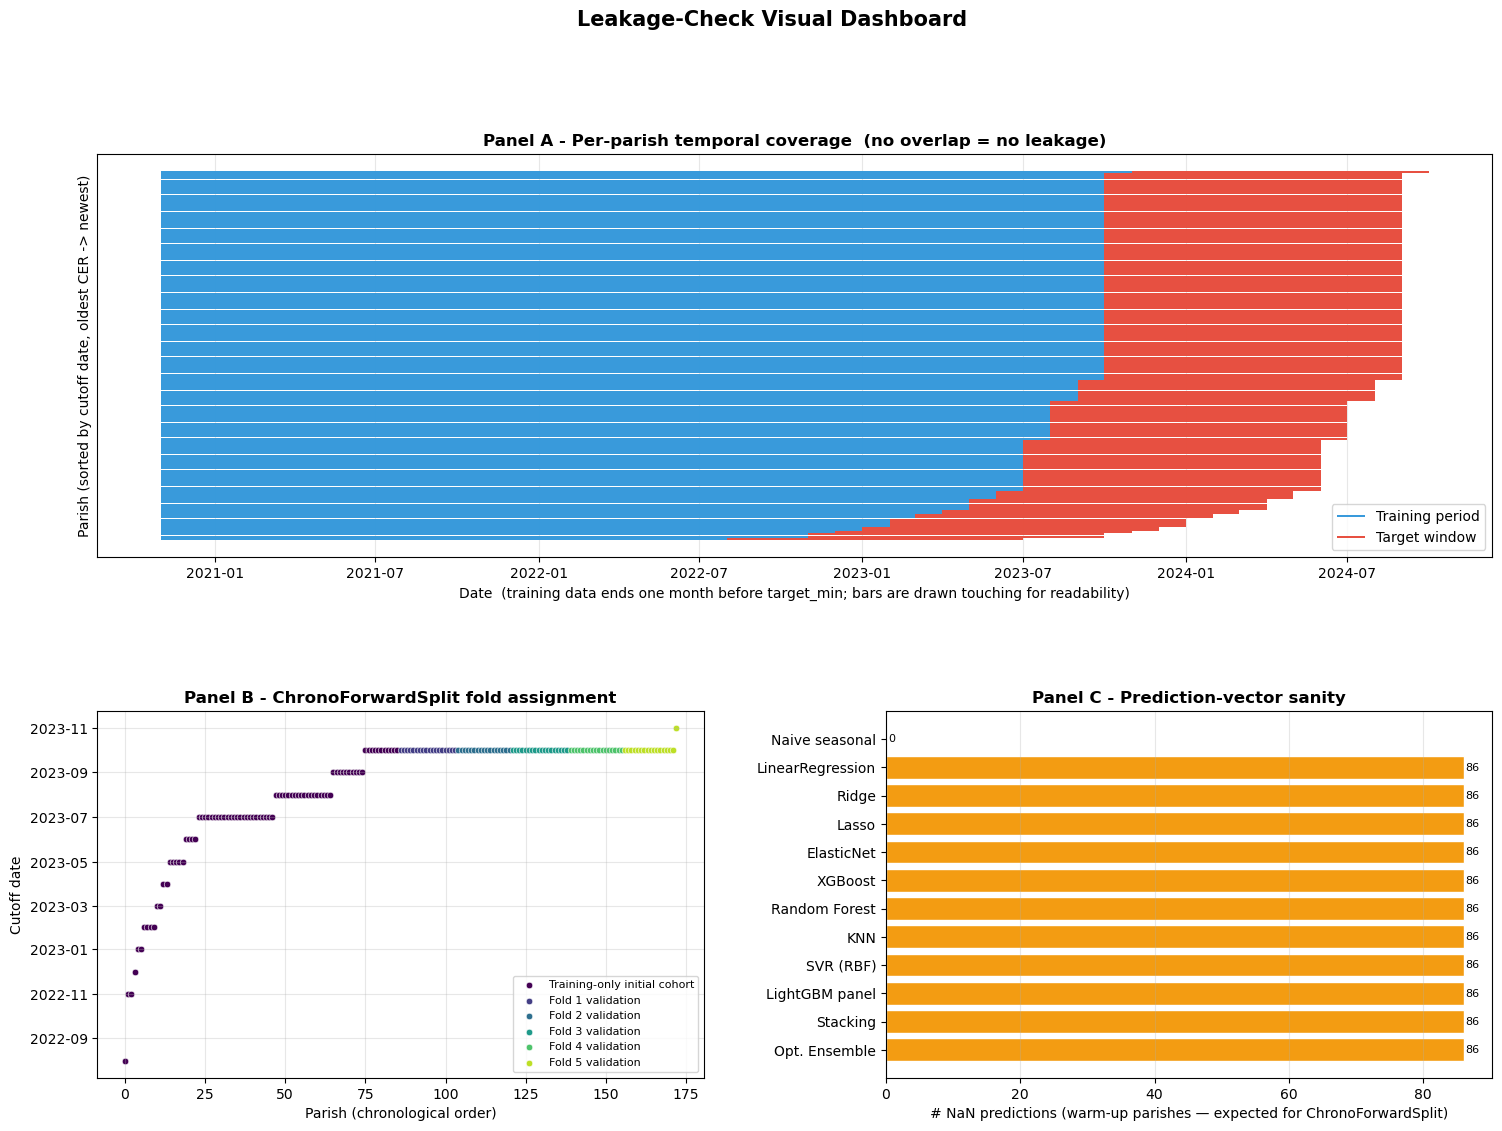

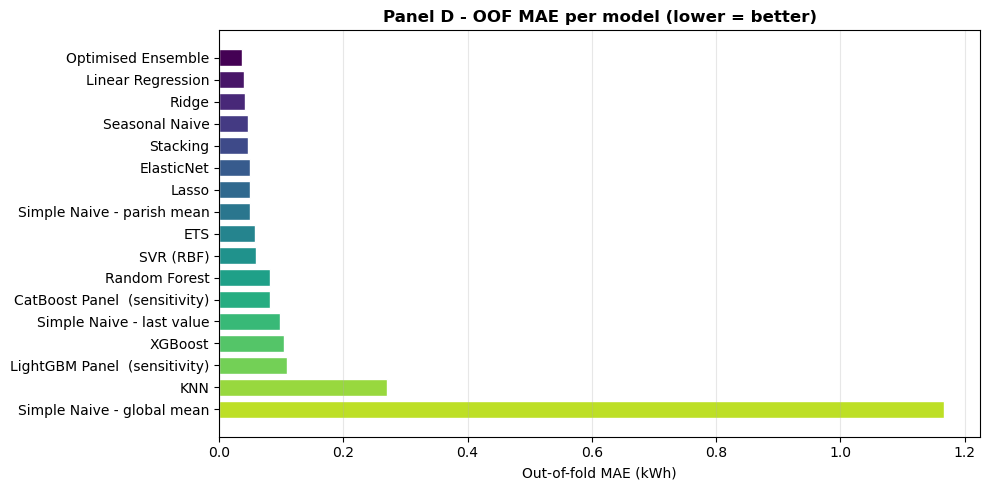


Leakage-check visual dashboard saved


In [28]:
# Leakage-Check Visual Dashboard

fig = plt.figure(figsize=(18, 12))
gs_v = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.30,
                          height_ratios=[1.1, 1.0])

# 1.Panel A: per-parish train/target temporal Gantt Alignment 
axA = fig.add_subplot(gs_v[0, :])
parish_order = cutoff_dates.sort_values().index
train_min = df_input.groupby('parish_code')['date'].min().reindex(parish_order)
train_max = df_input.groupby('parish_code')['date'].max().reindex(parish_order)
target_min = df_target.groupby('parish_code')['date'].min().reindex(parish_order)
target_max = df_target.groupby('parish_code')['date'].max().reindex(parish_order)

y_positions = np.arange(len(parish_order))

# Blue and red segments are extended to touch visually at the boundary month for plotting continuity.
axA.hlines(y_positions, train_min, target_min, colors='#3498db', linewidth=1.4, label='Training period')
axA.hlines(y_positions, target_min, target_max, colors='#e74c3c', linewidth=1.4, label='Target window')
axA.set_xlabel('Date  (training data ends one month before target_min; bars are drawn touching for readability)')
axA.set_ylabel('Parish (sorted by cutoff date, oldest CER -> newest)')
axA.set_title('Panel A - Per-parish temporal coverage  (no overlap = no leakage)',
              fontweight='bold')
axA.set_yticks([])
axA.legend(loc='lower right')
axA.grid(axis='x', alpha=0.3)

# 2. Panel B: ChronoForwardSplit fold assignment 
axB = fig.add_subplot(gs_v[1, 0])
bins = CV_OUTER._bin_assign(list(parish_order))
palette = plt.cm.viridis(np.linspace(0, 0.9, CV_OUTER.n_splits + 1))
fold_labels = ['Training-only initial cohort'] + [f'Fold {k+1} validation' for k in range(CV_OUTER.n_splits)]
for b in range(CV_OUTER.n_splits + 1):
    mask = bins == b
    axB.scatter(np.where(mask)[0],
                cutoff_dates.loc[parish_order].values[mask],
                color=palette[b], s=22, label=fold_labels[b], edgecolor='white', linewidth=0.4)
axB.set_xlabel('Parish (chronological order)')
axB.set_ylabel('Cutoff date')
axB.set_title('Panel B - ChronoForwardSplit fold assignment',
              fontweight='bold')
axB.legend(fontsize=8, loc='best')
axB.grid(alpha=0.3)

# 3. Panel C: prediction sanity NaN/Inf counts 
axC = fig.add_subplot(gs_v[1, 1])
pred_checks = {
    'Naive seasonal'     : naive_preds,
    'LinearRegression'   : lr_series,
    'Ridge'              : ridge_series,
    'Lasso'              : lasso_series,
    'ElasticNet'         : en_series,
    'XGBoost'            : xgb_series,
    'Random Forest'      : rf_series,
    'KNN'                : knn_series,
    'SVR (RBF)'          : svr_series,
    'LightGBM panel'     : lgbm_panel_series,
    'Stacking'           : stack_series,
    'Opt. Ensemble'      : opt_ensemble_series,
}
nan_counts = {name: int(s.reindex(Y.index).isna().sum()) for name, s in pred_checks.items()}
bars = axC.barh(list(nan_counts.keys()), list(nan_counts.values()),
                color=['#2ecc71' if v == 0 else '#f39c12' for v in nan_counts.values()],
                edgecolor='white')
axC.set_xlabel('# NaN predictions (warm-up parishes — expected for ChronoForwardSplit)')
axC.set_title('Panel C - Prediction-vector sanity', fontweight='bold')
for bar, v in zip(bars, nan_counts.values()):
    axC.text(v + 0.3, bar.get_y() + bar.get_height()/2, f'{v}',
             va='center', fontsize=8)
axC.invert_yaxis()
axC.grid(axis='x', alpha=0.3)

plt.suptitle('Leakage-Check Visual Dashboard', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('1_Models_Comparison_output/leakage_visual_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

#  Panel D: OOF MAE per model 
try:
    fig2, axD = plt.subplots(figsize=(10, 5))
    lb_d = leaderboard.copy()
    if isinstance(lb_d['MAE'].iloc[0], str):
        lb_d['MAE'] = lb_d['MAE'].str.replace(',', '').astype(float)
    lb_d = lb_d.sort_values('MAE')
    axD.barh(lb_d['Model'], lb_d['MAE'],
             color=plt.cm.viridis(np.linspace(0, 0.9, len(lb_d))), edgecolor='white')
    axD.set_xlabel('Out-of-fold MAE (kWh)')
    axD.set_title('Panel D - OOF MAE per model (lower = better)', fontweight='bold')
    axD.invert_yaxis()
    axD.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('1_Models_Comparison_output/leakage_visual_panel_d.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"  (Panel D skipped: {e})")

print("\nLeakage-check visual dashboard saved")



## 13. Alternative Framing: 12-Month Vector Forecast (Task B)

Up to this point, we have focused entirely on a single target: predicting the annual mean of consumption over the 12-month target window. To test how the models handle a more complex structure, this section introduces an alternate framing:

Task B: Predict all 12 individual monthly values of the target window simultaneously (a 12-dimensional vector output instead of a single scalar).

This multi-output setup uses our existing cross-sectional feature matrix $X_{cs}$ to benchmark three approaches:

- **Seasonal Naive (Vector)**: Replays the last 12 months of known history straight into the forecast window (a simple 12-month sequence shift).
- **Multi-Output Ridge**: Trains independent Ridge models for each step using MultiOutputRegressor, tuning regularization parameters across our chronological split.
- **Multi-Output XGBoost**: Fits a collection of gradient boosted trees across the 12 target horizons using stable, moderate hyperparameters for speed.

#### How this relates to the Panel Sensitivity Check
While Section 6 (Panel Sensitivity) ran data at the single row-per-month level to expand the training footprint, Task B keeps the row-per-parish structure but explodes the target column into a vector. Both methods check whether monthly data yields better accuracy.The baseline floor is tough to beat when predicting an annual mean, but Task B helps verify if our models are genuinely capturing structural intra-year seasonality or just predicting a flat line.


Building 12-month vector target matrix...
  Y_vec shape: (173, 12)  (parishes x target months)
Training multi-output Ridge (nested CV)...
Training multi-output XGBoost...


  12-MONTH VECTOR FORECAST LEADERBOARD
                     Model        MAE    MAE_min    MAE_max Time (s)
        12m Naive (vector)     0.0597     0.0506     0.0712      0.0
  12m Ridge (multi-output)     0.0663     0.0449     0.0885      8.9
12m XGBoost (multi-output)     0.1192     0.0989     0.1555      1.5


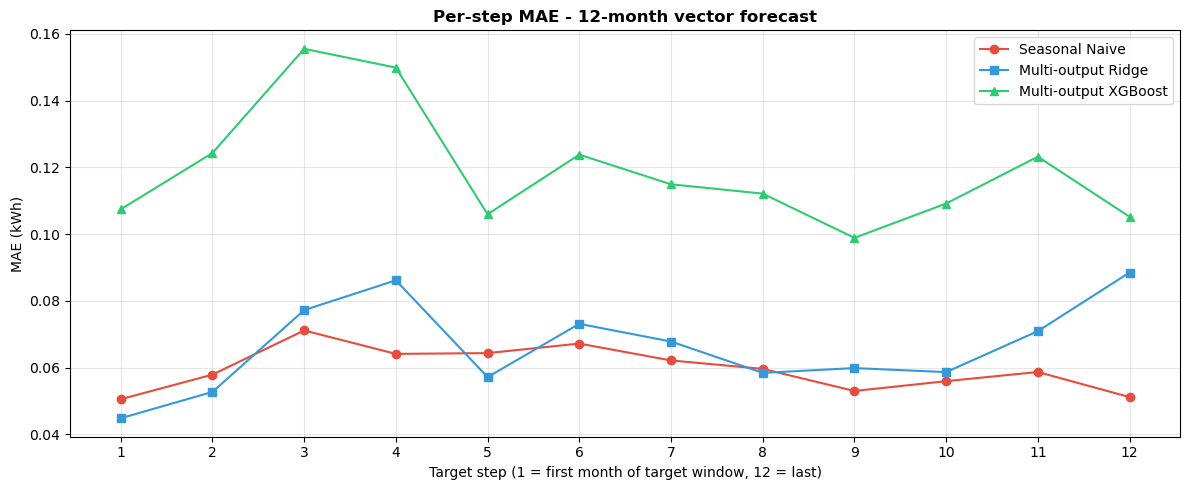


Reconciliation with Task A (annual mean derived from vector forecast):
  Multi-output Ridge  -> annual-mean MAE:     0.0472  (cf. Task-A Ridge MAE:     0.0422)
  Multi-output XGB    -> annual-mean MAE:     0.0913  (cf. Task-A XGB   MAE:     0.1044)

Task B (12-month vector forecast) complete


In [29]:
# Second Predictive Task: 12-month vector forecast

print("Building 12-month vector target matrix...")

# -- Build Y_vec: one row per parish, 12 columns (target months in chronological order)
df_target_sorted = df_target.sort_values(['parish_code', 'date']).copy()
df_target_sorted['target_step'] = (
    df_target_sorted.groupby('parish_code').cumcount()  # 0..11 per parish
)
Y_vec = (
    df_target_sorted
    .pivot(index='parish_code', columns='target_step', values='energy_kwh')
    .reindex(Y.index)
)
Y_vec.columns = [f'step_{i+1:02d}' for i in range(12)]
print(f"  Y_vec shape: {Y_vec.shape}  (parishes x target months)")

# 1. Seasonal Naive (vector) - replay the 12 months immediately before cutoff
naive_vec_rows = []
for parish, g in df_input.sort_values(['parish_code', 'date']).groupby('parish_code'):
    last12 = g['energy_kwh'].tail(12).values
    if len(last12) < 12:
        last12 = np.concatenate([np.full(12 - len(last12), last12.mean()), last12])
    naive_vec_rows.append((parish, *last12))
naive_vec = pd.DataFrame(
    naive_vec_rows,
    columns=['parish_code'] + [f'step_{i+1:02d}' for i in range(12)]
).set_index('parish_code').reindex(Y_vec.index)

# 2. Multi-output Ridge (nested CV: alpha tuned per outer fold)
print("Training multi-output Ridge (nested CV)...")
start = time.time()
ridge_vec_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler()),
    ('model',   Ridge()),
])
ridge_vec_gs = GridSearchCV(
    ridge_vec_pipe,
    {'model__alpha': [0.1, 1, 10, 50, 100, 500]},
    cv=ChronoForwardSplit(cutoff_dates, n_splits=3),
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)
ridge_vec_model = MultiOutputRegressor(ridge_vec_gs, n_jobs=-1)
# cross_val_predict is incompatible with ChronoForwardSplit because
# warm-up parishes are intentionally never assigned to validation folds.
ridge_vec_preds = pd.DataFrame(
    np.nan,
    index=Y_vec.index,
    columns=Y_vec.columns
)

for fold_id, (tr_idx, te_idx) in enumerate(KF_CS.split(X_cs), start=1):
    X_tr, X_te = X_cs.iloc[tr_idx], X_cs.iloc[te_idx]
    Y_tr = Y_vec.iloc[tr_idx]

    fold_model = MultiOutputRegressor(ridge_vec_gs, n_jobs=-1)
    fold_model.fit(X_tr, Y_tr)

    ridge_vec_preds.iloc[te_idx] = fold_model.predict(X_te)

time_ridge_vec = time.time() - start

#  3. Multi-output XGBoost 
print("Training multi-output XGBoost...")
start = time.time()
xgb_vec_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   XGBRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        random_state=RANDOM_STATE, tree_method='hist', verbosity=0)),
])
xgb_vec_model = MultiOutputRegressor(xgb_vec_pipe, n_jobs=-1)
xgb_vec_preds = pd.DataFrame(
    np.nan,
    index=Y_vec.index,
    columns=Y_vec.columns
)

for fold_id, (tr_idx, te_idx) in enumerate(KF_CS.split(X_cs), start=1):
    X_tr, X_te = X_cs.iloc[tr_idx], X_cs.iloc[te_idx]
    Y_tr = Y_vec.iloc[tr_idx]

    fold_model = MultiOutputRegressor(xgb_vec_pipe, n_jobs=-1)
    fold_model.fit(X_tr, Y_tr)

    xgb_vec_preds.iloc[te_idx] = fold_model.predict(X_te)

time_xgb_vec = time.time() - start

#   per-step MAE and overall MAE
def vector_metrics(y_true_df, y_pred_df, name, t):
    diff = (y_true_df - y_pred_df).abs()
    per_step = diff.mean(axis=0, skipna=True)
    overall  = np.nanmean(diff.values)
    return per_step.rename(name), {
        'Model'   : name,
        'MAE'     : overall,
        'MAE_min' : per_step.min(),
        'MAE_max' : per_step.max(),
        'Time (s)': t,
    }

ps_naive, sum_naive = vector_metrics(Y_vec, naive_vec,        '12m Naive (vector)', 0.0)
ps_ridge, sum_ridge = vector_metrics(Y_vec, ridge_vec_preds, '12m Ridge (multi-output)', time_ridge_vec)
ps_xgb,   sum_xgb   = vector_metrics(Y_vec, xgb_vec_preds,   '12m XGBoost (multi-output)', time_xgb_vec)

vector_leaderboard = pd.DataFrame([sum_naive, sum_ridge, sum_xgb]).sort_values('MAE')
print("\n")
print("  12-MONTH VECTOR FORECAST LEADERBOARD")
vl_disp = vector_leaderboard.copy()
for k in ['MAE', 'MAE_min', 'MAE_max']:
    vl_disp[k] = vl_disp[k].map('{:>10.4f}'.format)
vl_disp['Time (s)'] = vl_disp['Time (s)'].map('{:.1f}'.format)
print(vl_disp.to_string(index=False))

# Per-step plot: how does error change across the 12-month horizon
fig, ax = plt.subplots(1, 1, figsize=(12, 5))
ax.plot(range(1, 13), ps_naive.values, marker='o', label='Seasonal Naive', color='#e74c3c')
ax.plot(range(1, 13), ps_ridge.values, marker='s', label='Multi-output Ridge', color='#3498db')
ax.plot(range(1, 13), ps_xgb.values,   marker='^', label='Multi-output XGBoost', color='#2ecc71')
ax.set_xlabel('Target step (1 = first month of target window, 12 = last)')
ax.set_ylabel('MAE (kWh)')
ax.set_title('Per-step MAE - 12-month vector forecast', fontweight='bold')
ax.set_xticks(range(1, 13))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('1_Models_Comparison_output/vector_forecast_per_step.png', dpi=150, bbox_inches='tight')
plt.show()

# Reconciliation check: does the *mean* of the vector forecast match Task A?
ridge_vec_annual_mean = ridge_vec_preds.mean(axis=1)
xgb_vec_annual_mean   = xgb_vec_preds.mean(axis=1)
print("\nReconciliation with Task A (annual mean derived from vector forecast):")
print(f"  Multi-output Ridge  -> annual-mean MAE: {safe_mae(Y, ridge_vec_annual_mean):>10.4f}  "
      f"(cf. Task-A Ridge MAE: {safe_mae(Y, ridge_series):>10.4f})")
print(f"  Multi-output XGB    -> annual-mean MAE: {safe_mae(Y, xgb_vec_annual_mean):>10.4f}  "
      f"(cf. Task-A XGB   MAE: {safe_mae(Y, xgb_series):>10.4f})")

print("\nTask B (12-month vector forecast) complete")



## 14. White-Box Model Analysis - Ridge / Lasso Coefficients

Refit Ridge and Lasso on the **full** standardised cross-sectional matrix
`X_cs` (using the best alpha picked by an inner CV) and inspect the
coefficients. Because all features are on the same `RobustScaler` scale, the
coefficient magnitudes are directly comparable.


Refitting Ridge and Lasso on full X_cs for coefficient inspection...
  RidgeCV best alpha: 0.1
  LassoCV best alpha: 0.0100


  RIDGE & LASSO COEFFICIENTS (standardised, sorted by |Ridge coef|)
      feature ridge_coef lasso_coef lasso_zero
      roll_12       +0.5       +1.1           
      roll_24       +0.5       +0.1           
       roll_3       +0.5       +0.7           
       roll_6       +0.5       +0.0    dropped
    cv_energy       +0.1       +0.0    dropped
   volatility       -0.1       +0.0           
      hist_tp       -0.1       -0.0    dropped
       lag_12       +0.0       +0.0    dropped
    recent_tp       +0.0       -0.0    dropped
    t2m_trend       +0.0       +0.0    dropped
 momentum_3_6       +0.0       +0.0    dropped
   lag_spread       -0.0       -0.0           
    yoy_ratio       +0.0       -0.0    dropped
   last_month       +0.0       +0.0    dropped
       lag_24       -0.0       +0.1           
     hist_t2m       -0.0       +0.0    dropped
momentu

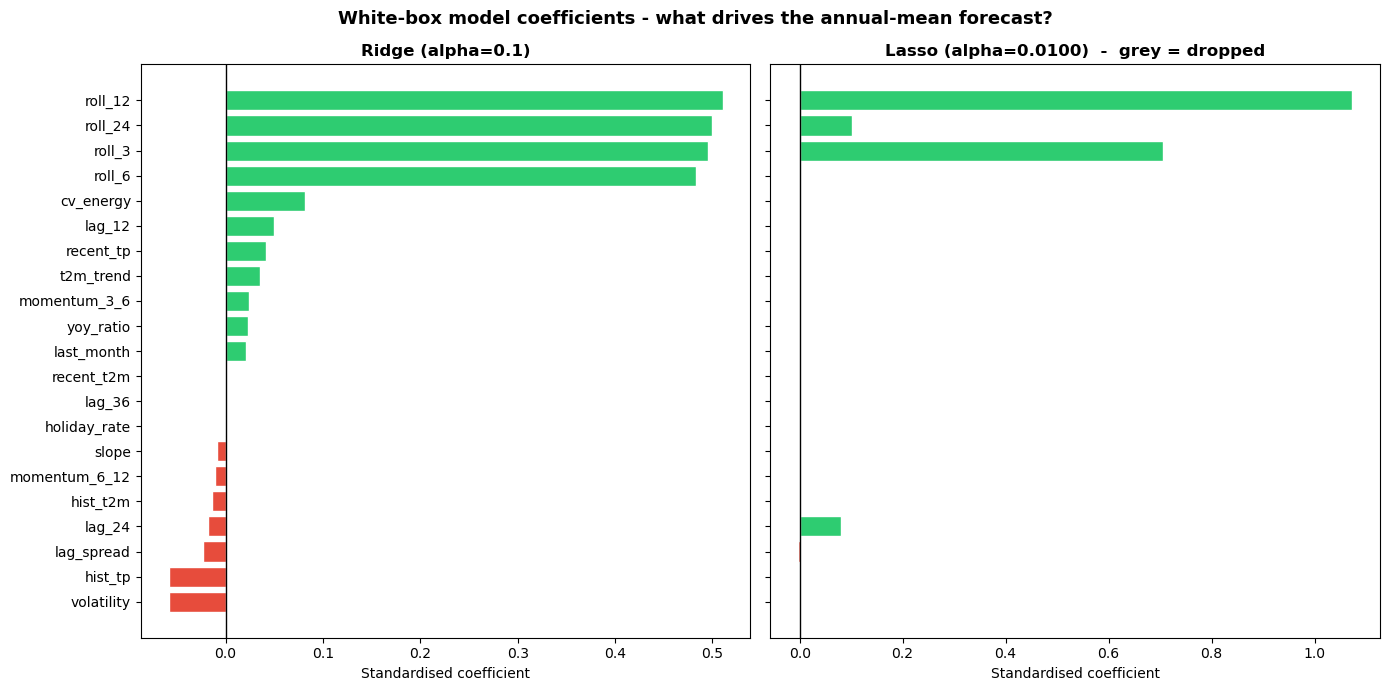



  INTERPRETATION

The three largest-magnitude Ridge coefficients are: roll_12, roll_24, roll_3.
Ridge keeps every feature in the model (alpha penalises but never eliminates),
while Lasso drops 15 feature(s) at its CV-optimal alpha - these are
the features whose marginal contribution is dominated by the retained ones,
which is the classic sign of collinearity in the cross-sectional matrix
(notably between roll_3 / roll_6 / roll_12, and between lag_12 / lag_24).

Sign check against intuition for the trend/momentum block:
  slope         : negative (down forecast)
  momentum_3_6  : positive (up forecast)
  momentum_6_12 : negative (down forecast)
  yoy_ratio     : positive (up forecast)

A positive slope or momentum coefficient means parishes whose recent consumption
is trending up are predicted to have a higher annual mean - consistent with a
naive extrapolation story. A negative coefficient on volatility (if observed)
would mean noisy parishes are pulled toward the cross-sectional ave

In [30]:
# CELL 19 - White-box analysis: standardised Ridge & Lasso coefficients

print("Refitting Ridge and Lasso on full X_cs for coefficient inspection...")

imp = SimpleImputer(strategy='median')
scl = RobustScaler()

X_cs_imputed = imp.fit_transform(X_cs)
X_cs_scaled  = scl.fit_transform(X_cs_imputed)
feat_names   = X_cs.columns.tolist()

ridge_wb = RidgeCV(alphas=[0.1, 1, 10, 50, 100, 500, 1000], cv=5).fit(X_cs_scaled, Y)
lasso_wb = LassoCV(alphas=[0.001, 0.01, 0.1, 1, 10, 50, 100], cv=5,
                   max_iter=20000).fit(X_cs_scaled, Y)

print(f"  RidgeCV best alpha: {ridge_wb.alpha_}")
print(f"  LassoCV best alpha: {lasso_wb.alpha_:.4f}")

coef_df = pd.DataFrame({
    'feature'    : feat_names,
    'ridge_coef' : ridge_wb.coef_,
    'lasso_coef' : lasso_wb.coef_,
})
coef_df['abs_ridge'] = coef_df['ridge_coef'].abs()
coef_df = coef_df.sort_values('abs_ridge', ascending=False).reset_index(drop=True)
coef_df['lasso_zero'] = (coef_df['lasso_coef'] == 0).map({True: 'dropped', False: ''})

# -- Print ranked coefficients
print("\n")
print("  RIDGE & LASSO COEFFICIENTS (standardised, sorted by |Ridge coef|)")
disp = coef_df[['feature', 'ridge_coef', 'lasso_coef', 'lasso_zero']].copy()
disp['ridge_coef'] = disp['ridge_coef'].map('{:+,.1f}'.format)
disp['lasso_coef'] = disp['lasso_coef'].map('{:+,.1f}'.format)
print(disp.to_string(index=False))
n_dropped = (coef_df['lasso_coef'] == 0).sum()
print(f"  Lasso dropped {n_dropped}/{len(coef_df)} features at alpha={lasso_wb.alpha_:.4f}.")

# -- Plot coefficients side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)

order = coef_df.sort_values('ridge_coef')['feature'].tolist()
ridge_ord = coef_df.set_index('feature').loc[order, 'ridge_coef']
lasso_ord = coef_df.set_index('feature').loc[order, 'lasso_coef']

colors_r = ['#2ecc71' if v >= 0 else '#e74c3c' for v in ridge_ord]
colors_l = ['#2ecc71' if v >  0 else ('#bdc3c7' if v == 0 else '#e74c3c') for v in lasso_ord]

axes[0].barh(ridge_ord.index, ridge_ord.values, color=colors_r, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title(f'Ridge (alpha={ridge_wb.alpha_})', fontweight='bold')
axes[0].set_xlabel('Standardised coefficient')

axes[1].barh(lasso_ord.index, lasso_ord.values, color=colors_l, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title(f'Lasso (alpha={lasso_wb.alpha_:.4f})  -  grey = dropped',
                  fontweight='bold')
axes[1].set_xlabel('Standardised coefficient')

plt.suptitle('White-box model coefficients - what drives the annual-mean forecast?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('1_Models_Comparison_output/whitebox_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()

# -- Interpretation
top3 = coef_df.head(3)['feature'].tolist()
def _sign(v):
    if v > 0: return 'positive (up forecast)'
    if v < 0: return 'negative (down forecast)'
    return 'zero'

print("\n")
print("  INTERPRETATION")
print(f"""
The three largest-magnitude Ridge coefficients are: {', '.join(top3)}.
Ridge keeps every feature in the model (alpha penalises but never eliminates),
while Lasso drops {n_dropped} feature(s) at its CV-optimal alpha - these are
the features whose marginal contribution is dominated by the retained ones,
which is the classic sign of collinearity in the cross-sectional matrix
(notably between roll_3 / roll_6 / roll_12, and between lag_12 / lag_24).

Sign check against intuition for the trend/momentum block:
  slope         : {_sign(coef_df.set_index('feature').loc['slope',         'ridge_coef'])}
  momentum_3_6  : {_sign(coef_df.set_index('feature').loc['momentum_3_6',  'ridge_coef'])}
  momentum_6_12 : {_sign(coef_df.set_index('feature').loc['momentum_6_12', 'ridge_coef'])}
  yoy_ratio     : {_sign(coef_df.set_index('feature').loc['yoy_ratio',     'ridge_coef'])}

A positive slope or momentum coefficient means parishes whose recent consumption
is trending up are predicted to have a higher annual mean - consistent with a
naive extrapolation story. A negative coefficient on volatility (if observed)
would mean noisy parishes are pulled toward the cross-sectional average, which
is the regularisation doing its job.

Practical takeaway: the cross-sectional Ridge model is dominated by the
level/lag features (roll_12, lag_12, roll_6), with trend features acting as
fine adjustments. Lasso's eliminations identify the redundant features inside
that block - a useful signal for any future feature-pruning pass.
""")
print("\nWhite-box analysis complete.")
